### Inisialisasi Pustaka dan Pembacaan Data Awal

Sel kode ini melakukan impor pustaka-pustaka penting seperti `mne` untuk analisis data M/EEG, `numpy` dan `pandas` untuk manipulasi data numerik, serta modul visualisasi dan pemrosesan sinyal. Kode ini juga mendemonstrasikan pembacaan awal file EDF menggunakan fungsi `mne.io.read_raw_edf` dengan parameter `preload=True` untuk memuat data ke memori, diikuti dengan ekstraksi dan pencetakan anotasi (marker kejadian) untuk memeriksa struktur data.

In [1]:
import os
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
from scipy.signal import butter, filtfilt, welch
from matplotlib.patches import Patch

# contoh 

edf_path = r"C:\Users\Henry\Documents\KULIAH\riset\EEG\EEGET-ALS Dataset\ALS03\time1\scenario1\EEG.edf"

raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

annotations = raw.annotations
print(annotations)

for annot in annotations:
    print(f"Onset: {annot['onset']} s, Duration: {annot['duration']} s, Description: {annot['description']}")

<Annotations | 3 segments: Resting (1), Think_Acting (1), Thinking (1)>
Onset: 16.5043 s, Duration: 7.0961 s, Description: Thinking
Onset: 23.6013 s, Duration: 7.3616 s, Description: Resting
Onset: 30.9639 s, Duration: 1.0361 s, Description: Think_Acting


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\2409981769.py:14: RuntimeWarning: Omitted 10 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\2409981769.py:14: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


### Konfigurasi Parameter dan Direktori

Bagian ini menetapkan variabel-variabel konfigurasi global yang digunakan di seluruh analisis:
- `DATASET_PATH` dan `OUTPUT_BASE`: Menentukan lokasi direktori input data dan output hasil. Direktori output akan dibuat jika belum ada.
- `CHANNELS`: Daftar saluran EEG yang akan dianalisis ('C3', 'C4').
- `SUBBANDS`: Definisi rentang frekuensi untuk filter bandpass (Alpha: 8-13 Hz, Beta: 13-30 Hz, Gamma: 30-49 Hz).
- `FEATURES`: Daftar fitur statistik yang akan diekstraksi (variansi, rata-rata, standar deviasi).
- `SCENARIOS`: Daftar label skenario eksperimen.

In [2]:
DATASET_PATH = r"C:\Users\Henry\Documents\KULIAH\riset\EEG\EEGET-ALS Dataset"
OUTPUT_BASE = r"C:\Users\Henry\Documents\KULIAH\riset\EEG\results_task_analysis"

if not os.path.exists(OUTPUT_BASE):
    os.makedirs(OUTPUT_BASE)

CHANNELS = ['C3', 'C4']
SUBBANDS = {
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 49)
}
FEATURES = ['variance', 'std']
SCENARIOS = ['scenario1', 'scenario2']

### Fungsi Konversi EDF ke CSV dengan Sinkronisasi Marker

Fungsi `edf_to_csv_with_markers` dirancang untuk mengubah data sinyal EEG dari format biner EDF menjadi format tabular CSV.
- **Ekstraksi Data:** Sinyal mentah diekstrak bersama dengan informasi waktu.
- **Sinkronisasi Marker:** Fungsi ini memetakan anotasi (event markers) dari file EDF ke timestamp yang sesuai di DataFrame. Jika marker memiliki durasi, seluruh rentang waktu ditandai; jika tidak (point event), sampel terdekat yang ditandai.
- **Output:** Hasil disimpan sebagai file CSV dengan kolom 'marker' yang berisi deskripsi event, memudahkan penggunaan dalam *supervised learning*.

In [3]:
# Fungsi untuk mengonversi EDF ke CSV dengan marker

def edf_to_csv_with_markers(edf_path, output_csv_path):
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        sfreq = raw.info['sfreq']
        
        data, times = raw.get_data(return_times=True)
        channel_names = raw.ch_names

        df = pd.DataFrame(data.T, columns=channel_names)
        df.insert(0, 'time', times) 
        
        df['marker'] = 'none'
        
        # Ekstrak annotations (markers)
        annotations = raw.annotations
        
        if len(annotations) > 0:
            # Assign marker ke setiap sample berdasarkan onset dan duration
            for annot in annotations:
                onset = annot['onset']
                duration = annot['duration']
                description = annot['description']
                
                # Cari index sample yang berada dalam rentang waktu marker
                if duration > 0:
                    # Marker dengan durasi
                    mask = (df['time'] >= onset) & (df['time'] < onset + duration)
                else:
                    # Marker tanpa durasi (point event), assign ke sample terdekat
                    idx = np.argmin(np.abs(df['time'] - onset))
                    mask = df.index == idx
                
                df.loc[mask, 'marker'] = description
        
        # Simpan ke CSV
        df.to_csv(output_csv_path, index=False)
        return True, len(annotations)
        
    except Exception as e:
        return False, str(e)


### Automasi Pemrosesan Batch Dataset

Sel ini mengimplementasikan loop iteratif untuk memproses seluruh dataset secara otomatis.
- **Iterasi Hierarkis:** Kode menelusuri struktur folder Subjek > Waktu > Skenario.
- **Pemrosesan File:** Setiap file `EEG.edf` yang ditemukan dikonversi menjadi CSV menggunakan fungsi `edf_to_csv_with_markers` yang telah didefinisikan sebelumnya.
- **Pelaporan:** Kode melacak dan mencetak jumlah file yang berhasil diproses, jumlah file yang memiliki marker valid, dan total file yang gagal diproses.

In [4]:

total_files = 0
success_count = 0
error_count = 0
files_with_markers = 0

# Loop semua subject
for subject in os.listdir(DATASET_PATH):
    # if subject == 'ALS%':
    
    subject_path = os.path.join(DATASET_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    
    # Loop semua time folder
    for time_folder in os.listdir(subject_path):
        time_path = os.path.join(subject_path, time_folder)
        if not os.path.isdir(time_path) or not time_folder.startswith('time'):
            continue
        
        # Loop semua scenario folder
        for scenario in os.listdir(time_path):
            scenario_path = os.path.join(time_path, scenario)
            if not os.path.isdir(scenario_path):
                continue
            
            edf_file = os.path.join(scenario_path, "EEG.edf")
            
            if not os.path.exists(edf_file):
                continue
            
            total_files += 1
            
            # Output path
            output_csv = os.path.join(scenario_path, "eeg_marker.csv")
            
            # Convert
            success, result = edf_to_csv_with_markers(edf_file, output_csv)
            
            if success:
                success_count += 1
                if result > 0:  # result = jumlah annotations
                    files_with_markers += 1
                    print(f"[OK] {subject}/{time_folder}/{scenario} - {result} markers")
                else:
                    print(f"[OK] {subject}/{time_folder}/{scenario} - No markers")
            else:
                error_count += 1

C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\1439024524.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


[OK] ALS01/time1/scenario2 - 7 markers
[OK] ALS01/time1/scenario3 - 7 markers
[OK] ALS01/time1/scenario4 - 7 markers
[OK] ALS01/time1/scenario5 - 7 markers
[OK] ALS01/time1/scenario6 - 7 markers
[OK] ALS01/time1/scenario7 - 7 markers
[OK] ALS01/time10/scenario1 - 7 markers
[OK] ALS01/time10/scenario2 - 7 markers
[OK] ALS01/time10/scenario3 - 7 markers
[OK] ALS01/time10/scenario4 - 7 markers
[OK] ALS01/time10/scenario5 - 7 markers
[OK] ALS01/time10/scenario6 - 7 markers
[OK] ALS01/time10/scenario7 - 7 markers
[OK] ALS01/time10/scenario8 - 7 markers
[OK] ALS01/time10/scenario9 - 7 markers
[OK] ALS01/time2/scenario3 - 7 markers
[OK] ALS01/time2/scenario4 - 7 markers
[OK] ALS01/time2/scenario5 - 7 markers
[OK] ALS01/time2/scenario6 - 7 markers
[OK] ALS01/time2/scenario7 - 7 markers
[OK] ALS01/time3/scenario1 - 7 markers
[OK] ALS01/time3/scenario2 - 7 markers
[OK] ALS01/time3/scenario3 - 7 markers
[OK] ALS01/time3/scenario4 - 7 markers
[OK] ALS01/time3/scenario5 - 7 markers
[OK] ALS01/time3

C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\1439024524.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


[OK] ALS01/time4/scenario1 - 7 markers
[OK] ALS01/time4/scenario2 - 7 markers
[OK] ALS01/time4/scenario3 - 7 markers
[OK] ALS01/time4/scenario4 - 7 markers
[OK] ALS01/time4/scenario5 - 7 markers
[OK] ALS01/time4/scenario6 - 7 markers
[OK] ALS01/time4/scenario7 - 7 markers
[OK] ALS01/time4/scenario8 - 7 markers
[OK] ALS01/time4/scenario9 - 7 markers
[OK] ALS01/time5/scenario1 - 7 markers
[OK] ALS01/time5/scenario2 - 7 markers
[OK] ALS01/time5/scenario3 - 7 markers
[OK] ALS01/time5/scenario4 - 7 markers
[OK] ALS01/time5/scenario5 - 7 markers
[OK] ALS01/time5/scenario6 - 7 markers
[OK] ALS01/time5/scenario7 - 7 markers


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\1439024524.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


...

[OK] id85/time1/scenario3 - 13 markers
[OK] id85/time1/scenario4 - 13 markers
[OK] id85/time1/scenario5 - 13 markers
[OK] id85/time1/scenario6 - 13 markers
[OK] id85/time1/scenario7 - 13 markers
[OK] id85/time1/scenario8 - 7 markers
[OK] id85/time1/scenario9 - 7 markers
[OK] id86/time1/scenario1 - 13 markers
[OK] id86/time1/scenario2 - 13 markers
[OK] id86/time1/scenario3 - 13 markers
[OK] id86/time1/scenario4 - 13 markers
[OK] id86/time1/scenario5 - 13 markers
[OK] id86/time1/scenario6 - 13 markers
[OK] id86/time1/scenario7 - 13 markers
[OK] id86/time1/scenario8 - 7 markers
[OK] id86/time1/scenario9 - 7 markers
[OK] id87/time1/scenario1 - 13 markers
[OK] id87/time1/scenario2 - 13 markers
[OK] id87/time1/scenario3 - 13 markers
[OK] id87/time1/scenario4 - 13 markers
[OK] id87/time1/scenario5 - 13 markers
[OK] id87/time1/scenario6 - 13 markers
[OK] id87/time1/scenario7 - 11 markers
[OK] id87/time1/scenario8 - 7 markers
[OK] id87/time1/scenario9 - 7 markers
[OK] id88/time1/scenario1 - 13 

C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\1439024524.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


[OK] id94/time1/scenario3 - 13 markers
[OK] id94/time1/scenario4 - 13 markers
[OK] id94/time1/scenario5 - 13 markers
[OK] id94/time1/scenario6 - 11 markers
[OK] id94/time1/scenario7 - 13 markers


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\1439024524.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


[OK] id94/time1/scenario8 - 7 markers
[OK] id94/time1/scenario9 - 7 markers
[OK] id95/time1/scenario1 - 13 markers
[OK] id95/time1/scenario2 - 13 markers
[OK] id95/time1/scenario3 - 13 markers
[OK] id95/time1/scenario4 - 13 markers
[OK] id95/time1/scenario5 - 13 markers
[OK] id95/time1/scenario6 - 13 markers
[OK] id95/time1/scenario7 - 13 markers
[OK] id95/time1/scenario8 - 6 markers
[OK] id95/time1/scenario9 - 7 markers
[OK] id96/time1/scenario1 - 13 markers
[OK] id96/time1/scenario2 - 13 markers
[OK] id96/time1/scenario3 - 13 markers
[OK] id96/time1/scenario4 - 13 markers
[OK] id96/time1/scenario5 - 13 markers
[OK] id96/time1/scenario6 - 13 markers
[OK] id96/time1/scenario7 - 13 markers
[OK] id96/time1/scenario8 - 7 markers
[OK] id96/time1/scenario9 - 7 markers
[OK] id97/time1/scenario1 - 13 markers
[OK] id97/time1/scenario2 - 13 markers
[OK] id97/time1/scenario3 - 13 markers
[OK] id97/time1/scenario4 - 13 markers
[OK] id97/time1/scenario5 - 13 markers
[OK] id97/time1/scenario6 - 13 

### Fungsi Utilitas: Filter Bandpass dan Ekstraksi Fitur

Sel ini mendefinisikan fungsi-fungsi pemrosesan sinyal dasar:
1.  **`bandpass_filter`**: Mengimplementasikan filter IIR Butterworth orde-4. Fungsi `scipy.signal.filtfilt` digunakan untuk menerapkan filter secara maju-mundur (zero-phase filtering), memastikan tidak ada distorsi fasa pada sinyal yang difilter.
2.  **`compute_feature`**: Menghitung statistik deskriptif dari sinyal:
    - `variance`: Mengukur penyebaran data (`np.var`).
    - `mean`: Menghitung nilai rata-rata sinyal (`np.mean`).
    - `std`: Menghitung standar deviasi (`np.std`).

In [5]:
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def compute_feature(data, feature_name):
    if feature_name == 'variance':
        return np.var(data)
    elif feature_name == 'mean':
        return np.mean(data)
    elif feature_name == 'std':
        return np.std(data)
    return None

### Penjelasan Preprocessing Sinyal EEG: Justifikasi dan Dampaknya

Sinyal EEG yang direkam dari kulit kepala selalu mengandung campuran aktivitas otak yang diinginkan dengan berbagai sumber noise (artefak). Preprocessing bertujuan untuk meningkatkan Signal-to-Noise Ratio (SNR) sehingga fitur yang diekstraksi lebih mencerminkan aktivitas neural sesungguhnya.

---

#### Tahap 1: Bandpass Filtering (0.5 - 49 Hz)

**Apa yang dilakukan:**
Filter Finite Impulse Response (FIR) dari MNE (`raw.filter()`) digunakan untuk meloloskan sinyal hanya pada rentang 0.5-49 Hz.

**Mengapa harus digunakan:**
- **Batas bawah 0.5 Hz:** Membuang komponen DC offset dan drift elektroda lambat yang muncul akibat impedansi kontak elektroda-kulit dan keringat. Komponen di bawah 0.5 Hz bukan berasal dari aktivitas neural.
- **Batas atas 49 Hz:** Membuang noise interferensi jala listrik (power line noise) pada 50 Hz serta noise frekuensi tinggi dari kontraksi otot (EMG noise). Aktivitas otak yang relevan untuk analisis motor (Alpha, Beta, Gamma) berada di bawah 49 Hz.

**Benefit:**
Sinyal menjadi lebih bersih dari gangguan non-neural berfrekuensi sangat rendah dan sangat tinggi, sehingga tahap analisis selanjutnya bekerja pada data yang lebih representatif.

**Cara menentukan rentang frekuensi:**
Dipilih berdasarkan rentang frekuensi sub-pita EEG standar yang akan dianalisis. Karena sub-pita tertinggi dalam analisis ini adalah Gamma (30-49 Hz), maka batas atas filter ditetapkan di 49 Hz. Batas bawah 0.5 Hz adalah konvensi umum untuk membuang drift tanpa menghilangkan komponen Delta (0.5-4 Hz).

---

#### Tahap 2: Notch Filter (50 Hz)

**Apa yang dilakukan:**
Notch filter (band-stop filter) pada 50 Hz menghapus komponen frekuensi spesifik pada tepat 50 Hz dan harmoniknya. MNE menggunakan fungsi `raw.notch_filter()` yang menerapkan filter band-stop sempit di sekitar frekuensi target.

**Mengapa harus digunakan:**
- Jaringan listrik PLN di Indonesia beroperasi pada frekuensi 50 Hz. Interferensi elektromagnetik dari kabel listrik, lampu, dan perangkat elektronik di sekitar lokasi perekaman masuk ke sinyal EEG melalui impedansi elektroda.
- Bandpass filter dengan batas atas 49 Hz sudah membuang sebagian besar noise 50 Hz, namun jika sampling rate cukup tinggi dan transisi filter tidak cukup tajam, residu 50 Hz masih bisa bocor. Notch filter memastikan penghapusan total komponen 50 Hz.
- Berbeda dengan bandpass filter yang memotong seluruh rentang frekuensi, notch filter hanya menghapus pita frekuensi sangat sempit (biasanya 49-51 Hz), sehingga komponen sinyal neural di frekuensi sekitarnya tidak terganggu.

**Benefit:**
Menghilangkan kontaminasi jala listrik secara presisi tanpa mengorbankan informasi sinyal pada frekuensi tetangga. Ini penting terutama untuk analisis sub-pita Gamma (30-49 Hz) yang berada dekat dengan frekuensi jala listrik.

---

#### Tahap 3: Independent Component Analysis (ICA)

**Apa yang dilakukan:**
ICA mendekomposisi sinyal multikanal menjadi komponen-komponen statistik yang secara spasial dan temporal independen satu sama lain. Setelah dekomposisi, komponen yang teridentifikasi sebagai artefak dapat dihapus, dan sinyal direkonstruksi dari komponen yang tersisa.
#### Tahap 4: Subband Decomposition (Bandpass per Sub-pita)
**Mengapa harus digunakan:**
- **Artefak okular (kedipan mata dan gerakan mata):** Menghasilkan sinyal besar di kanal frontal yang menyebar ke kanal lain termasuk C3 dan C4. ICA dapat mengisolasi komponen ini.
- **Artefak otot (EMG):** Kontraksi otot wajah dan leher menghasilkan aktivitas broadband frekuensi tinggi yang sulit dihilangkan hanya dengan filter.
- **Artefak kardiak (ECG):** Detak jantung menghasilkan pola periodik yang bisa bercampur dengan sinyal otak.

**Benefit:**
ICA menghapus artefak secara selektif tanpa membuang seluruh segmen data, sehingga lebih banyak data yang dapat dipertahankan dibandingkan metode rejection berbasis threshold.

**Cara menentukan parameter:**
- `n_components=10`: Disesuaikan dengan jumlah kanal. Umumnya dipilih 10-20 komponen untuk dataset dengan 14-64 kanal.
- Dalam implementasi saat ini, ICA diterapkan secara otomatis (`ica.apply`) tanpa seleksi manual komponen artefak. Untuk analisis yang lebih ketat, sebaiknya dilakukan inspeksi visual atau deteksi otomatis komponen artefak menggunakan `ica.find_bads_eog()` atau `ica.find_bads_ecg()`.

---

#### Tahap 3: Subband Decomposition (Bandpass per Sub-pita)

**Apa yang dilakukan:**
Setelah preprocessing, sinyal dipecah ke dalam sub-pita frekuensi terpisah menggunakan filter Butterworth orde-4 dengan metode zero-phase (`filtfilt`).

**Sub-pita dan justifikasinya:**
- **Alpha (8-13 Hz):** Berkaitan dengan kondisi relaksasi dan inhibisi kortikal. Pada analisis motorik, penurunan power Alpha (Event-Related Desynchronization / ERD) mengindikasikan aktivasi area motorik.
- **Beta (13-30 Hz):** Terkait dengan perencanaan dan eksekusi motorik. Event-Related Synchronization (ERS) pada Beta mengindikasikan penghambatan atau pemulihan motorik.
- **Gamma (30-49 Hz):** Diasosiasikan dengan proses kognitif tingkat tinggi dan integrasi informasi sensorimotor.

### Fungsi Ekstraksi Tugas: Dual Mode (Preprocessed vs Raw)

**Benefit:**

Memungkinkan analisis terpisah per band frekuensi, yang masing-masing mencerminkan mekanisme neural berbeda. Ini penting karena patologi seperti ALS dapat mempengaruhi band tertentu secara selektif.---



---Sel-sel berikut mengimplementasikan dua pipeline: satu dengan preprocessing (Bandpass + ICA) dan satu tanpa preprocessing (raw), beserta perbandingannya.



#### Mengapa Perlu Baseline Tanpa Preprocessing?Untuk memvalidasi bahwa preprocessing benar-benar meningkatkan kualitas analisis, diperlukan perbandingan dengan data tanpa preprocessing (raw). Jika fitur dari data yang sudah dipreprocessing menghasilkan pemisahan yang lebih baik antara kelompok ALS dan Control, maka preprocessing terbukti memberikan nilai tambah. Sebaliknya, jika hasilnya serupa, preprocessing mungkin tidak diperlukan atau perlu disesuaikan.


In [ ]:
def extract_tasks_from_edf(edf_path, use_bandpass=True, use_notch=True, use_ica=True):
    """
    Extract task segments from EDF file based on annotations.
    
    Parameters:
    -----------
    edf_path : str
        Path ke file EDF.
    use_bandpass : bool
        Terapkan Bandpass Filter (0.5-49 Hz).
    use_notch : bool
        Terapkan Notch Filter (50 Hz).
    use_ica : bool
        Terapkan ICA untuk artifact removal.
    
    Returns:
    --------
    task_segments : dict
        {task_name: {channel: data_array}}
    sfreq : float
        Sampling frequency.
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        sfreq = raw.info['sfreq']
        
        raw_processed = raw.copy()
        
        # NOTE: Preprocessing applied sequentially if flag is True
        
        # 1. Bandpass Filter
        if use_bandpass:
            raw_processed.filter(0.5, 49, verbose=False)
            
        # 2. Notch Filter
        if use_notch:
            raw_processed.notch_filter(freqs=50, verbose=False)
            
        # 3. ICA
        if use_ica:
            ica = ICA(n_components=10, random_state=42, max_iter='auto', )
            ica.fit(raw_processed, verbose=False)
            raw_processed = raw_processed.copy()
            ica.apply(raw_processed, verbose=False)
        
        # Get annotations
        annotations = raw_processed.annotations
        
        if len(annotations) == 0:
            task_segments = {}
            for ch in CHANNELS:
                if ch in raw_processed.ch_names:
                    data_ch = raw_processed.copy().pick([ch]).get_data()[0]
                    if 'full_recording' not in task_segments:
                        task_segments['full_recording'] = {}
                    task_segments['full_recording'][ch] = data_ch
            return task_segments, sfreq
        
        # Extract task segments based on annotations
        task_segments = {}
        
        for annot in annotations:
            onset = annot['onset']
            duration = annot['duration']
            task_name = annot['description'].strip()
            
            # Normalisasi nama task: Gabungkan 'thinking and acting' menjadi 'think_acting'
            if task_name == 'Thinking and Acting':
                task_name = 'Think_Acting'
                
            
            if duration <= 0:
                continue
            
            start_idx = int(onset * sfreq)
            end_idx = int((onset + duration) * sfreq)
            
            if task_name not in task_segments:
                task_segments[task_name] = {}
            
            for ch in CHANNELS:
                if ch in raw_processed.ch_names:
                    data_ch = raw_processed.copy().pick([ch]).get_data()[0]
                    segment = data_ch[start_idx:end_idx]
                    
                    if ch not in task_segments[task_name]:
                        task_segments[task_name][ch] = segment
                    else:
                        task_segments[task_name][ch] = np.concatenate([
                            task_segments[task_name][ch], segment
                        ])
        
        return task_segments, sfreq
        
    except Exception as e:
        print(f"Error processing {edf_path}: {e}")
        return None, None

### Pipeline Analisis Fitur: Preprocessed vs Raw (Baseline)

Kode berikut menjalankan pipeline ekstraksi fitur dua kali secara sekuensial:
1. **Preprocessed (`preprocess=True`):** Sinyal melewati Bandpass Filter + ICA sebelum ekstraksi fitur.
2. **Raw / Baseline (`preprocess=False`):** Sinyal digunakan apa adanya tanpa filter atau ICA.

Kedua hasil disimpan dalam DataFrame terpisah (`df_preprocessed` dan `df_raw`) dengan kolom tambahan `pipeline` untuk membedakan asal data. Kemudian digabungkan ke dalam `df_all` untuk analisis perbandingan.

In [7]:
def run_feature_extraction(label, use_bandpass=True, use_notch=True, use_ica=True):
    """
    Menjalankan pipeline ekstraksi fitur dengan parameter preprocessing spesifik.
    """
    results_als = []
    results_control = []
    file_count = 0
    
    for subject in os.listdir(DATASET_PATH):
        subject_path = os.path.join(DATASET_PATH, subject)
        if not os.path.isdir(subject_path):
            continue
        
        for time_folder in os.listdir(subject_path):
            time_path = os.path.join(subject_path, time_folder)
            if not os.path.isdir(time_path) or not time_folder.startswith('time'):
                continue
            
            for scenario in SCENARIOS:
                scenario_path = os.path.join(time_path, scenario)
                edf_file = os.path.join(scenario_path, "EEG.edf")
                
                if not os.path.exists(edf_file):
                    continue
                
                file_count += 1
                
                # Extract tasks dengan mode preprocessing yang dipilih
                task_segments, sfreq = extract_tasks_from_edf(
                    edf_file, 
                    use_bandpass=use_bandpass,
                    use_notch=use_notch,
                    use_ica=use_ica
                )
                
                if task_segments is None:
                    continue
                
                for task_name, channels_data in task_segments.items():
                    for channel, data in channels_data.items():
                        for subband_name, (low, high) in SUBBANDS.items():
                            subband_data = bandpass_filter(data, low, high, sfreq)
                            
                            for feature_name in FEATURES:
                                feature_value = compute_feature(subband_data, feature_name)
                                group = 'ALS' if subject.startswith('ALS') else 'Control'
                                
                                if group == 'ALS':
                                    results_als.append({
                                        'subject': subject,
                                        'time': time_folder,
                                        'scenario': scenario,
                                        'group': group,
                                        'task': task_name,
                                        'channel': channel,
                                        'subband': subband_name,
                                        'feature': feature_name,
                                        'value': feature_value,
                                        'pipeline': label
                                })
                                else:
                                    results_control.append({
                                        'subject': subject,
                                        'time': time_folder,
                                        'scenario': scenario,
                                        'group': group,
                                        'task': task_name,
                                        'channel': channel,
                                        'subband': subband_name,
                                        'feature': feature_name,
                                        'value': feature_value,
                                        'pipeline': label
                                })
                            
    
    df_als = pd.DataFrame(results_als)
    df_control = pd.DataFrame(results_control)
    if len(df_als) > 0 or len(df_control) > 0:
        print(f"[{label.upper()}] Files processed: {file_count}, Records ALS: {len(df_als)}, Records Control: {len(df_control)}")
    else:
         print(f"[{label.upper()}] No records found. Files processed: {file_count}")
    return df_als, df_control

# --- Jalankan pipelines untuk perbandingan ---

# 1. Pipeline WITH_NOTCH (Bandpass + Notch + ICA)
print("=" * 60)
print("PIPELINE 1: WITH_NOTCH (Bandpass + Notch + ICA)")
print("=" * 60)
df_with_notch_als, df_with_notch_control = run_feature_extraction('with_notch', use_bandpass=True, use_notch=True, use_ica=True)

# 2. Pipeline NO_NOTCH (Bandpass + ICA saja)
print("\n" + "=" * 60)
print("PIPELINE 2: NO_NOTCH (Bandpass + ICA)")
print("=" * 60)
df_no_notch_als, df_no_notch_control = run_feature_extraction('no_notch', use_bandpass=True, use_notch=False, use_ica=True)

# 3. Pipeline RAW (Baseline)
print("\n" + "=" * 60)
print("PIPELINE 3: RAW / BASELINE (Tanpa Preprocessing)")
print("=" * 60)
df_raw_als, df_raw_control = run_feature_extraction('raw', use_bandpass=False, use_notch=False, use_ica=False)

# Gabungkan hasil dari ketiga pipeline
df_all_als = pd.concat([df_with_notch_als, df_no_notch_als, df_raw_als], ignore_index=True)
df_all_control = pd.concat([df_with_notch_control, df_no_notch_control, df_raw_control], ignore_index=True)
df_all = pd.concat([df_all_als, df_all_control], ignore_index=True)
print(f"\n{'=' * 60}")
print(f"Total records (gabungan): {len(df_all)}")
print(f"Unique tasks: {df_all['task'].unique()}")
print(f"Unique subjects: {df_all['subject'].nunique()}")
print(f"Pipeline breakdown:")
print(df_all['pipeline'].value_counts().to_string())

PIPELINE 1: WITH_NOTCH (Bandpass + Notch + ICA)


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
c:\Users\Henry\Documents\KULIAH\riset\EEG\.venv\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Henry\Documents\KULIAH\riset\EEG\.venv\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 

[WITH_NOTCH] Files processed: 331, Records ALS: 3012, Records Control: 11844

PIPELINE 2: NO_NOTCH (Bandpass + ICA)


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
c:\Users\Henry\Documents\KULIAH\riset\EEG\.venv\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
c:\Users\Henry\Documents\KULIAH\riset\EEG\.venv\lib\site-packages\sklearn\decomposition\_fastica.py:127: Con

[NO_NOTCH] Files processed: 331, Records ALS: 3012, Records Control: 11844

PIPELINE 3: RAW / BASELINE (Tanpa Preprocessing)


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Omitted 10 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside t

[RAW] Files processed: 331, Records ALS: 3012, Records Control: 11844

Total records (gabungan): 44568
Unique tasks: ['Thinking' 'Resting' 'Typing' 'Think_Acting']
Unique subjects: 138
Pipeline breakdown:
pipeline
with_notch    14856
no_notch      14856
raw           14856


In [8]:
df_with_notch_als

,subject,time,scenario,group,task,channel,subband,feature,value,pipeline
0,ALS01,time1,scenario2,ALS,Thinking,C3,alpha,variance,0.000100,with_notch
1,ALS01,time1,scenario2,ALS,Thinking,C3,alpha,std,0.009992,with_notch
2,ALS01,time1,scenario2,ALS,Thinking,C3,beta,variance,0.000175,with_notch
3,ALS01,time1,scenario2,ALS,Thinking,C3,beta,std,0.013235,with_notch
4,ALS01,time1,scenario2,ALS,Thinking,C3,gamma,variance,0.000096,with_notch
...,...,...,...,...,...,...,...,...,...,...
3007,ALS06,time1,scenario2,ALS,Typing,C4,alpha,std,0.005209,with_notch
3008,ALS06,time1,scenario2,ALS,Typing,C4,beta,variance,0.000024,with_notch
3009,ALS06,time1,scenario2,ALS,Typing,C4,beta,std,0.004873,with_notch
3010,ALS06,time1,scenario2,ALS,Typing,C4,gamma,variance,0.000011,with_notch


In [9]:
df_all_als.head()

,subject,time,scenario,group,task,channel,subband,feature,value,pipeline
0,ALS01,time1,scenario2,ALS,Thinking,C3,alpha,variance,0.000100,with_notch
1,ALS01,time1,scenario2,ALS,Thinking,C3,alpha,std,0.009992,with_notch
2,ALS01,time1,scenario2,ALS,Thinking,C3,beta,variance,0.000175,with_notch
3,ALS01,time1,scenario2,ALS,Thinking,C3,beta,std,0.013235,with_notch
4,ALS01,time1,scenario2,ALS,Thinking,C3,gamma,variance,0.000096,with_notch


In [10]:
df_all.head()

,subject,time,scenario,group,task,channel,subband,feature,value,pipeline
0,ALS01,time1,scenario2,ALS,Thinking,C3,alpha,variance,0.000100,with_notch
1,ALS01,time1,scenario2,ALS,Thinking,C3,alpha,std,0.009992,with_notch
2,ALS01,time1,scenario2,ALS,Thinking,C3,beta,variance,0.000175,with_notch
3,ALS01,time1,scenario2,ALS,Thinking,C3,beta,std,0.013235,with_notch
4,ALS01,time1,scenario2,ALS,Thinking,C3,gamma,variance,0.000096,with_notch


### Penyimpanan Hasil dan Perhitungan Delta (Absolute Difference)

Bagian ini menangani dua tugas pasca-analisis:
1.  **Pengorganisasian Output:** Menyimpan hasil fitur ke dalam struktur folder hierarkis `output/Task/Channel/Subband/Feature` dalam format CSV, dipisahkan per skenario.
2.  **Perhitungan Delta:** Mengukur perbedaan kuantitatif antara Skenario 1 dan Skenario 2 menggunakan nilai absolut selisih (Delta).
    - Data dari kedua skenario dipasangkan (merged) berdasarkan subjek.
    - Menghitung **Mean Delta** (Rata-rata selisih absolut) antara vektor fitur kedua skenario.
    - Hasil perhitungan jarak disimpan untuk analisis perbandingan kinerja atau respons subjek antar skenario.
</VSCode.Cell>

In [11]:
# Create folder structure and save

def save_feature_data(df_all):
    for task in df_all['task'].unique():
        for channel in CHANNELS:
            for subband in SUBBANDS.keys():
                for feature in FEATURES:
                    
                    # Create folder
                    folder_path = os.path.join(OUTPUT_BASE, task, channel, subband, feature)
                    os.makedirs(folder_path, exist_ok=True)
                    
                    # Filter data
                    df_subset = df_all[
                        (df_all['task'] == task) &
                        (df_all['channel'] == channel) &
                        (df_all['subband'] == subband) &
                        (df_all['feature'] == feature)
                    ]
                    
                    if len(df_subset) == 0:
                        continue
                    
                    # Save per scenario
                    for scenario in SCENARIOS:
                        df_sc = df_subset[df_subset['scenario'] == scenario]
                        if len(df_sc) > 0:
                            csv_path = os.path.join(folder_path, f"{scenario}.csv")
                            df_sc.to_csv(csv_path, index=False)

    delta_variance_results = []
    delta_std_results = []

    for task in df_all['task'].unique():
        for channel in CHANNELS:
            for subband in SUBBANDS.keys():
                for feature in FEATURES:
                    df_sc1 = df_all[
                        (df_all['task'] == task) &
                        (df_all['channel'] == channel) &
                        (df_all['subband'] == subband) &
                        (df_all['feature'] == feature) &
                        (df_all['scenario'] == 'scenario1')
                    ].copy()
                    
                    df_sc2 = df_all[
                        (df_all['task'] == task) &
                        (df_all['channel'] == channel) &
                        (df_all['subband'] == subband) &
                        (df_all['feature'] == feature) &
                        (df_all['scenario'] == 'scenario2')
                    ].copy()
                    
                    if len(df_sc1) == 0 or len(df_sc2) == 0:
                        continue
                    
                    # Merge by subject + time for paired comparison
                    df_merged = pd.merge(
                        df_sc1[['subject', 'time', 'group', 'value']],
                        df_sc2[['subject', 'time', 'value']],
                        on=['subject', 'time'],
                        suffixes=('_sc1', '_sc2')
                    )
                    
                    if len(df_merged) == 0:
                        continue
                    
                    # Calculate Delta (Absolute Difference)
                    vec_sc1 = df_merged['value_sc1'].values
                    vec_sc2 = df_merged['value_sc2'].values
                    if feature == 'variance':
                        var_sc1 = np.var(vec_sc1)
                        var_sc2 = np.var(vec_sc2)
                        var_delta = np.mean(np.abs(var_sc1 - var_sc2))
                    
                        delta_variance_results.append({
                            'task': task,
                            'channel': channel,
                            'subband': subband,
                            'feature': feature,
                            'var_delta': var_delta,
                            'var_sc1': var_sc1,
                            'var_sc2': var_sc2,
                            'n_samples': len(df_merged)

                        })
                        df_merged['delta'] = np.abs(df_merged['value_sc1'] - df_merged['value_sc2'])
                        folder_path = os.path.join(OUTPUT_BASE, task, channel, subband, feature)
                        os.makedirs(folder_path, exist_ok=True)
                        
                        # Hapus file delta lama jika ada
                        old_file = os.path.join(folder_path, f"delta_{feature}_distances.csv")
                        if os.path.exists(old_file):
                            try:
                                os.remove(old_file)
                            except:
                                pass
                                
                        df_merged.to_csv(os.path.join(folder_path, f"delta_{feature}_values.csv"), index=False)
                            
                    

                    elif feature == 'std':
                        std_sc1 = np.std(vec_sc1)
                        std_sc2 = np.std(vec_sc2)
                    
                        # Use Mean of Absolute Differences (Mean Delta)
                        std_delta = np.mean(np.abs(std_sc1 - std_sc2))
                        
                        delta_std_results.append({
                            'task': task,
                            'channel': channel,
                            'subband': subband,
                            'feature': feature,
                            'std_delta': std_delta,
                            'std_sc1': std_sc1,
                            'std_sc2': std_sc2,
                            'n_samples': len(df_merged)

                        })

                        df_merged['delta'] = np.abs(df_merged['value_sc1'] - df_merged['value_sc2'])
                        folder_path = os.path.join(OUTPUT_BASE, task, channel, subband, feature)
                        os.makedirs(folder_path, exist_ok=True)
                        
                        # Hapus file delta lama jika ada
                        old_file = os.path.join(folder_path, f"delta_{feature}_distances.csv")
                        if os.path.exists(old_file):
                            try:
                                os.remove(old_file)
                            except:
                                pass
                                
                        df_merged.to_csv(os.path.join(folder_path, f"delta_{feature}_values.csv"), index=False)
                            
                    

    return pd.DataFrame(delta_variance_results), pd.DataFrame(delta_std_results)

In [12]:
df_variance_no_notch_als, df_std_no_notch_als = save_feature_data(df_no_notch_als)
df_variance_no_notch_control, df_std_no_notch_control = save_feature_data(df_no_notch_control)
df_variance_with_notch_als, df_std_with_notch_als = save_feature_data(df_with_notch_als)
df_variance_with_notch_control, df_std_with_notch_control = save_feature_data(df_with_notch_control)
df_variance_raw_als, df_std_raw_als = save_feature_data(df_raw_als)
df_variance_raw_control, df_std_raw_control = save_feature_data(df_raw_control)

dict_df = {
    'df_variance_no_notch_als': df_variance_no_notch_als,
    'df_variance_no_notch_control': df_variance_no_notch_control,
    'df_variance_with_notch_als': df_variance_with_notch_als,
    'df_variance_with_notch_control': df_variance_with_notch_control,
    'df_variance_raw_als': df_variance_raw_als,
    'df_variance_raw_control': df_variance_raw_control,
    'df_std_no_notch_als': df_std_no_notch_als,
    'df_std_no_notch_control': df_std_no_notch_control,
    'df_std_with_notch_als': df_std_with_notch_als,
    'df_std_with_notch_control': df_std_with_notch_control,
    'df_std_raw_als': df_std_raw_als,
    'df_std_raw_control': df_std_raw_control}
    

In [13]:
# print("\nDelta Summary (NO_NOTCH - ALS):")
# df_no_notch_als_delta.head()
# print("\nDelta Summary (NO_NOTCH - Control):")
# df_no_notch_control_delta.head()
# print("\nDelta Summary (WITH_NOTCH - ALS):")
# df_with_notch_als_delta.head()
print("\nDelta Summary (WITH_NOTCH - Control):")
df_std_with_notch_control
# print("\nDelta Summary (RAW - ALS):")
# df_raw_als_delta.head()
# print("\nDelta Summary (RAW - Control):")
# df_raw_control_delta


Delta Summary (WITH_NOTCH - Control):


,task,channel,subband,feature,std_delta,std_sc1,std_sc2,n_samples
0,Thinking,C3,alpha,std,0.000149,0.004089,0.003940,115
1,Thinking,C3,beta,std,0.000018,0.002055,0.002073,115
2,Thinking,C3,gamma,std,0.000055,0.001460,0.001515,115
3,Thinking,C4,alpha,std,0.000129,0.004315,0.004186,115
4,Thinking,C4,beta,std,0.000122,0.002127,0.002249,115
5,Thinking,C4,gamma,std,0.000102,0.001478,0.001580,115
6,Resting,C3,alpha,std,0.000131,0.002417,0.002548,115
7,Resting,C3,beta,std,0.000041,0.002318,0.002359,115
8,Resting,C3,gamma,std,0.000100,0.001559,0.001659,115
9,Resting,C4,alpha,std,0.000363,0.002060,0.002423,115


In [14]:
df_variance_with_notch_als

,task,channel,subband,feature,var_delta,var_sc1,var_sc2,n_samples
0,Thinking,C3,alpha,variance,1.983585e-09,3.230045e-09,1.246460e-09,34
1,Thinking,C3,beta,variance,3.677933e-10,2.233980e-09,1.866187e-09,34
2,Thinking,C3,gamma,variance,6.121276e-10,1.018004e-09,4.058766e-10,34
3,Thinking,C4,alpha,variance,1.107828e-09,3.514487e-09,2.406658e-09,34
4,Thinking,C4,beta,variance,6.658603e-10,2.557940e-09,1.892079e-09,34
5,Thinking,C4,gamma,variance,5.957044e-10,1.114077e-09,5.183728e-10,34
6,Resting,C3,alpha,variance,2.775897e-09,3.931377e-09,1.155480e-09,34
7,Resting,C3,beta,variance,8.929110e-10,2.104893e-09,2.997804e-09,34
8,Resting,C3,gamma,variance,3.445704e-10,1.196057e-09,8.514862e-10,34
9,Resting,C4,alpha,variance,5.276591e-09,6.378878e-09,1.102287e-09,34


### Visualisasi Data dan Ringkasan Statistik

Sel ini menghasilkan visualisasi grafis untuk menginterpretasikan hasil analisis Delta:
1.  **Tabel Ringkasan:** Menyimpan daftar kombinasi fitur yang diurutkan berdasarkan Delta rata-rata tertinggi ke file CSV.
2.  **Bar Plot:** Menampilkan 20 kombinasi fitur teratas yang membedakan skenario.
3.  **Heatmap:** Menampilkan peta panas rata-rata Delta untuk setiap tugas.
4.  **Scatter Plot:** Menghasilkan plot sebar detail untuk setiap fitur, membandingkan nilai individual Skenario 1 vs Skenario 2.
</VSCode.Cell>

In [15]:
df_std_with_notch_control

,task,channel,subband,feature,std_delta,std_sc1,std_sc2,n_samples
0,Thinking,C3,alpha,std,0.000149,0.004089,0.003940,115
1,Thinking,C3,beta,std,0.000018,0.002055,0.002073,115
2,Thinking,C3,gamma,std,0.000055,0.001460,0.001515,115
3,Thinking,C4,alpha,std,0.000129,0.004315,0.004186,115
4,Thinking,C4,beta,std,0.000122,0.002127,0.002249,115
5,Thinking,C4,gamma,std,0.000102,0.001478,0.001580,115
6,Resting,C3,alpha,std,0.000131,0.002417,0.002548,115
7,Resting,C3,beta,std,0.000041,0.002318,0.002359,115
8,Resting,C3,gamma,std,0.000100,0.001559,0.001659,115
9,Resting,C4,alpha,std,0.000363,0.002060,0.002423,115


In [16]:
df_variance_with_notch_control

,task,channel,subband,feature,var_delta,var_sc1,var_sc2,n_samples
0,Thinking,C3,alpha,variance,7.839119e-10,5.969393e-09,5.185481e-09,115
1,Thinking,C3,beta,variance,2.441616e-10,1.080132e-09,1.324293e-09,115
2,Thinking,C3,gamma,variance,2.453001e-11,2.865850e-10,3.111151e-10,115
3,Thinking,C4,alpha,variance,4.189516e-12,6.635689e-09,6.631499e-09,115
4,Thinking,C4,beta,variance,5.048382e-10,1.111840e-09,1.616678e-09,115
5,Thinking,C4,gamma,variance,4.791063e-11,3.178983e-10,3.658090e-10,115
6,Resting,C3,alpha,variance,2.535059e-10,9.580010e-10,1.211507e-09,115
7,Resting,C3,beta,variance,3.385485e-10,1.447222e-09,1.785771e-09,115
8,Resting,C3,gamma,variance,7.450369e-11,3.003871e-10,3.748908e-10,115
9,Resting,C4,alpha,variance,7.535587e-10,6.293156e-10,1.382874e-09,115


In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def visualize_paired_top20(dict_df, output_base):
    """
    Visualisasi berpasangan: Kiri (Variance) vs Kanan (Std) per Skenario.
    """
    
    OUTPUT_BASE_VIS = os.path.join(output_base, "visualizations_combined")
    os.makedirs(OUTPUT_BASE_VIS, exist_ok=True)
    
    # 1. Definisi Daftar Skenario (Base Names)
    # Ini kunci utamanya: Kita list dulu skenario apa saja yang ada
    scenarios = [
        'no_notch_als', 
        'no_notch_control',
        'with_notch_als', 
        'with_notch_control',
        'raw_als', 
        'raw_control'
    ]
    
    n_scenarios = len(scenarios)
    
    # Setup Figure: Baris = Jumlah Skenario, Kolom = 2 (Kiri: Var, Kanan: Std)
    fig, axes = plt.subplots(nrows=n_scenarios, ncols=2, figsize=(24, 10 * n_scenarios))
    
    # Handling jika cuma 1 skenario biar gak error indexing
    if n_scenarios == 1:
        axes = axes.reshape(1, -1)

    print(f"Generating paired plots for {n_scenarios} scenarios...")

    for idx, sc_name in enumerate(scenarios):
        # Construct Keys untuk mengambil DataFrame dari dictionary
        key_var = f"df_variance_{sc_name}"
        key_std = f"df_std_{sc_name}"
        
        # Cek apakah key ada di dictionary
        if key_var not in dict_df or key_std not in dict_df:
            print(f"Skipping {sc_name}: DataFrame not found.")
            continue
            
        df_var_raw = dict_df[key_var]
        df_std_raw = dict_df[key_std]
        
        # --- PROSES PLOT KIRI (VARIANCE) ---
        ax_var = axes[idx, 0]
        if len(df_var_raw) > 0:
            df_v = df_var_raw.copy()
            
            # Cleaning Column Names (jika ada spasi/pagar seperti di screenshot)
            df_v.columns = [c.strip().replace('# ', '') for c in df_v.columns]
            
            # Pastikan kolom delta ada (nama kolom biasanya 'var_delta')
            delta_col = 'var_delta' if 'var_delta' in df_v.columns else df_v.columns[0] # Fallback
            
            # Buat Label
            df_v['label'] = (df_v['task'].astype(str) + '_' + 
                             df_v['channel'] + '_' + 
                             df_v['subband'] + '_' + 
                             df_v['feature'])
            
            # Ambil Top 20
            df_top_v = df_v.sort_values(delta_col, ascending=False).head(20)
            
            # Plot
            colors_v = ['steelblue' if ch == 'C3' else 'coral' for ch in df_top_v['channel']]
            ax_var.barh(range(len(df_top_v)), df_top_v[delta_col], color=colors_v, edgecolor='black')
            ax_var.set_yticks(range(len(df_top_v)))
            ax_var.set_yticklabels(df_top_v['label'], fontsize=10)
            ax_var.invert_yaxis()
            ax_var.set_title(f"[{sc_name}] Top 20 VARIANCE Delta", fontsize=14, fontweight='bold')
            ax_var.set_xlabel("Variance Delta")
            ax_var.grid(axis='x', linestyle='--', alpha=0.5)

        # --- PROSES PLOT KANAN (STD DEV) ---
        ax_std = axes[idx, 1]
        if len(df_std_raw) > 0:
            df_s = df_std_raw.copy()
            
            # Cleaning Column Names
            df_s.columns = [c.strip().replace('# ', '') for c in df_s.columns]
            
            # Pastikan kolom delta ada (nama kolom biasanya 'std_delta')
            delta_col_s = 'std_delta' if 'std_delta' in df_s.columns else df_s.columns[0]
            
            # Buat Label
            df_s['label'] = (df_s['task'].astype(str) + '_' + 
                             df_s['channel'] + '_' + 
                             df_s['subband'] + '_' + 
                             df_s['feature'])
            
            # Ambil Top 20
            df_top_s = df_s.sort_values(delta_col_s, ascending=False).head(20)
            
            # Plot
            colors_s = ['steelblue' if ch == 'C3' else 'coral' for ch in df_top_s['channel']]
            ax_std.barh(range(len(df_top_s)), df_top_s[delta_col_s], color=colors_s, edgecolor='black')
            ax_std.set_yticks(range(len(df_top_s)))
            ax_std.set_yticklabels(df_top_s['label'], fontsize=10)
            ax_std.invert_yaxis()
            ax_std.set_title(f"[{sc_name}] Top 20 STD DEV Delta", fontsize=14, fontweight='bold')
            ax_std.set_xlabel("Std Dev Delta")
            ax_std.grid(axis='x', linestyle='--', alpha=0.5)
            
            # Legend (Cukup di kanan)
            legend_elements = [Patch(facecolor='steelblue', label='Channel C3'), 
                               Patch(facecolor='coral', label='Channel C4')]
            ax_std.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    
    output_path = os.path.join(OUTPUT_BASE_VIS, "Summary_Paired_Top20.png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[DONE] Visualization saved at: {output_path}")


Generating paired plots for 6 scenarios...


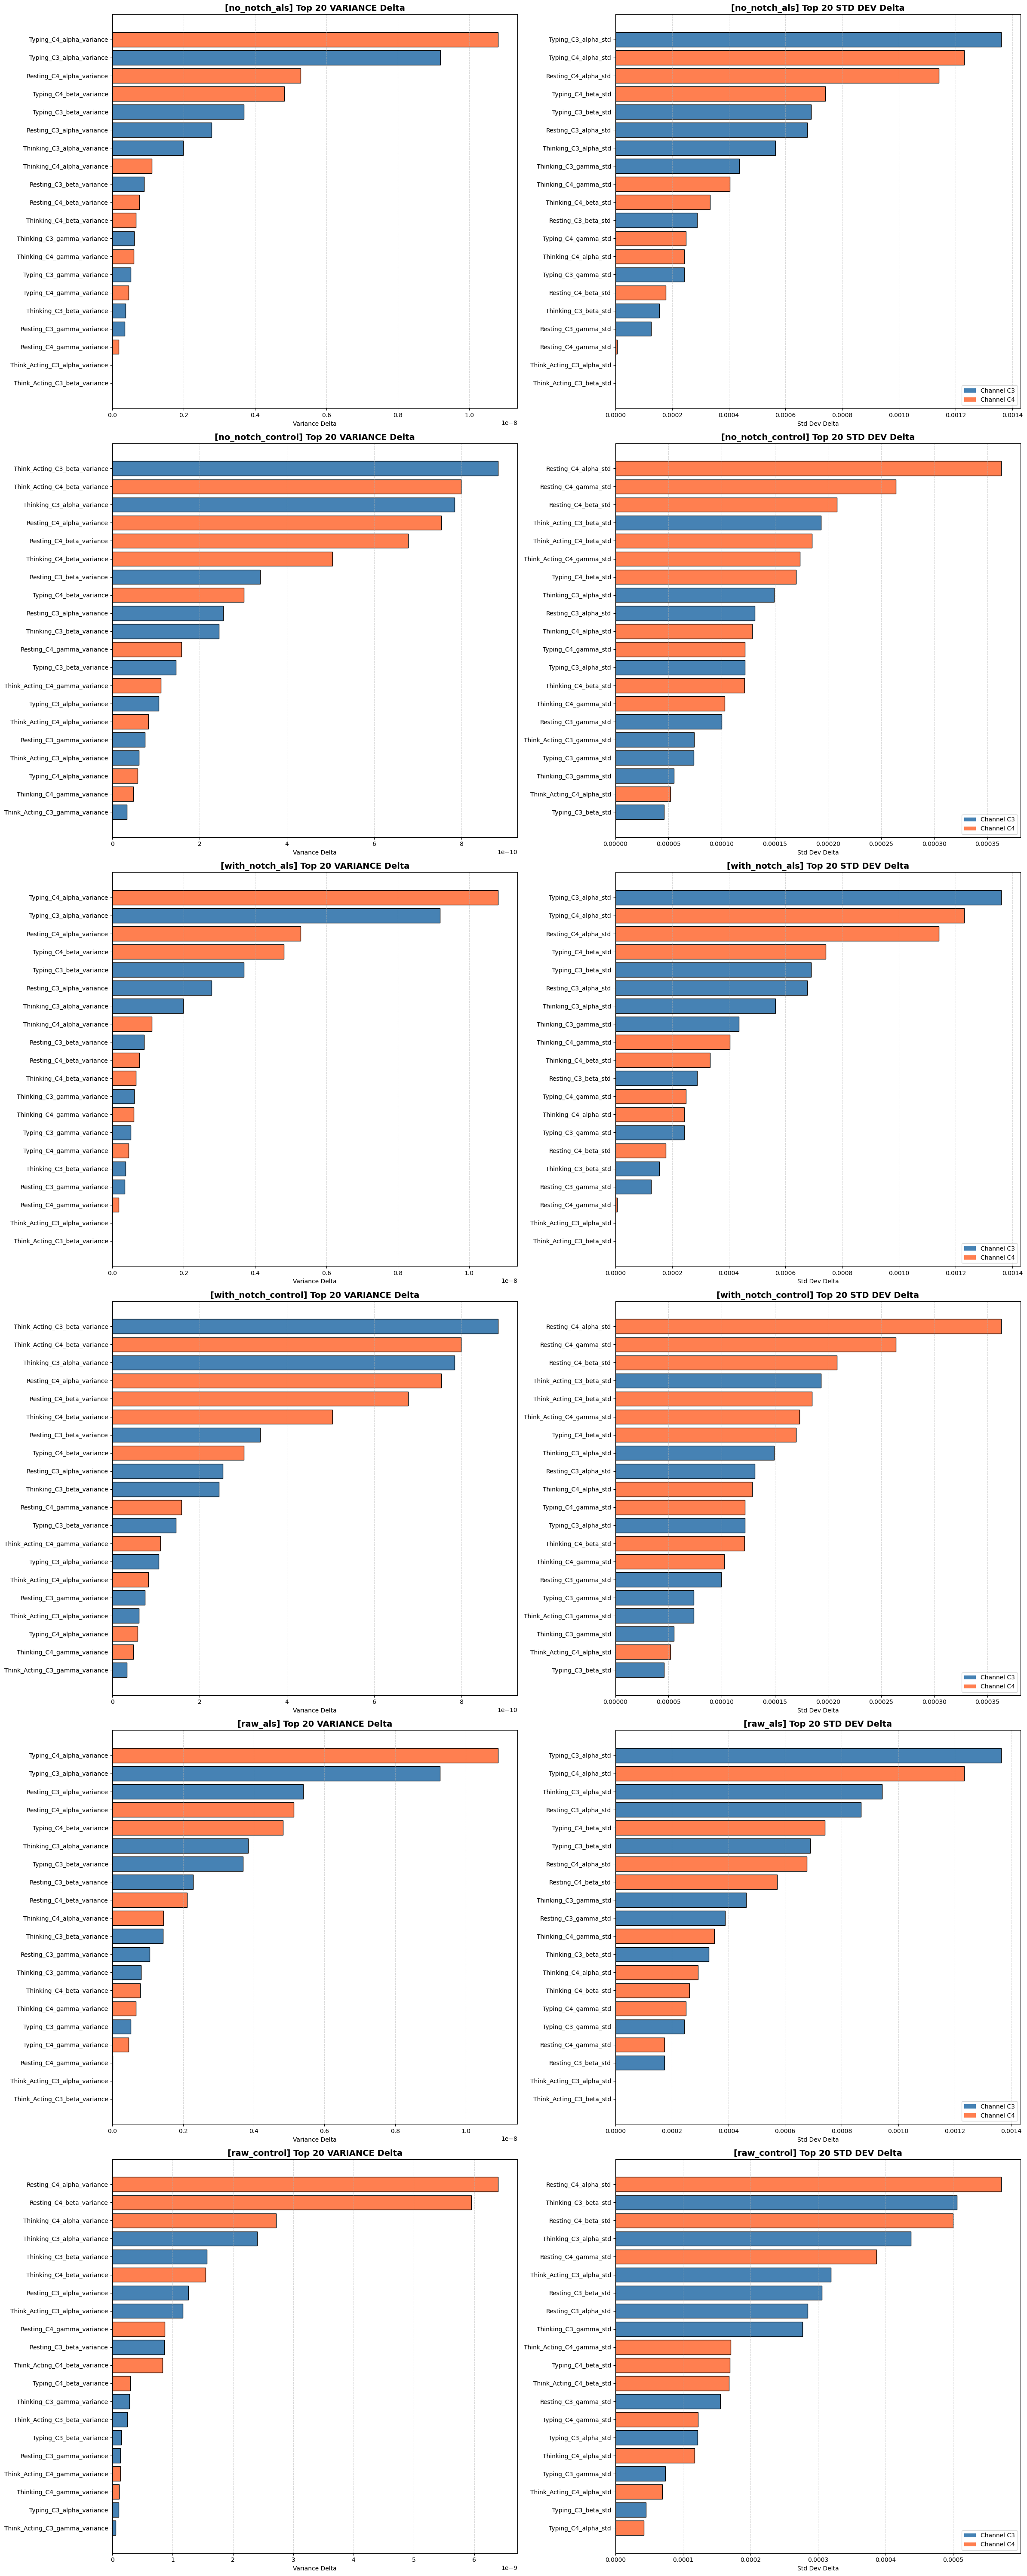

[DONE] Visualization saved at: C:\Users\Henry\Documents\KULIAH\riset\EEG\results_task_analysis\visualizations_combined\Summary_Paired_Top20.png


In [18]:


# Panggil fungsi (Loop sudah ada di dalam):
visualize_paired_top20(dict_df, OUTPUT_BASE)

In [19]:
# ============================================================
# PERBANDINGAN MULTI-PIPELINE (DELTA vs RAW) - ALL DICT_DF ENTRIES
# ============================================================

OUTPUT_COMPARISON = os.path.join(OUTPUT_BASE, "preprocessing_comparison")
os.makedirs(OUTPUT_COMPARISON, exist_ok=True)

# --- 1. Statistik Deskriptif per Pipeline dan Group ---
print("=" * 70)
print("1. STATISTIK DESKRIPTIF")
print("=" * 70)

if 'df_all' in locals():
    stats_comparison = df_all.groupby(
        ['pipeline', 'group', 'channel', 'subband', 'feature']
    )['value'].agg(['mean', 'std', 'count']).reset_index()

    stats_comparison.to_csv(
        os.path.join(OUTPUT_COMPARISON, "stats_comparison.csv"), index=False
    )

    pipelines_list = df_all['pipeline'].unique()
    for pipeline in pipelines_list:
        print(f"\n--- {pipeline.upper()} ---")
        df_pipe = stats_comparison[stats_comparison['pipeline'] == pipeline]
        print(df_pipe.head(5).to_string(index=False)) 
else:
    print("Variable 'df_all' tidak ditemukan. Melewati statistik deskriptif.")
    pipelines_list = []

# --- 2. DELTA COMPARISON (Based on dict_df) ---
print(f"\n{'=' * 70}")
print("2. DELTA (MEAN ABSOLUTE DIFFERENCE) COMPARISON (Scenario 1 vs Scenario 2)")
print("BANDINGIN SEMUA YANG ADA DI dict_df")
print("=" * 70)

delta_results = []
dict_keys_found = []

if 'dict_df' in locals():
    print(f"Menggunakan data dari 'dict_df'. Ditemukan {len(dict_df)} entries.")
    
    for key_name, df_result in dict_df.items():
        # df_result contains 'mean_euclidean_dist' which EQUALS Mean Delta (Mean Abs Diff)
        # We will use this value but label it 'mean_delta'
        
        if df_result is None or df_result.empty:
            print(f"Skipping empty entry: {key_name}")
            continue
            
        dict_keys_found.append(key_name)
        df_temp = df_result.copy()
        
        # Rename column for clarity (if needed) or just use it
        # mean_euclidean_dist = np.mean(np.abs(vec1 - vec2)) -> Ini adalah Delta Rata-rata
        if 'mean_euclidean_dist' in df_temp.columns:
            df_temp['mean_delta'] = df_temp['mean_euclidean_dist']
        else:
            print(f"Warning: 'mean_euclidean_dist' not found in {key_name}. Available: {df_temp.columns.tolist()}")
            continue

        # "untuk outputnya tolong tambahin name dari dict nya"
        df_temp['source_dict'] = key_name 
        
        # Select important columns
        cols_to_keep = ['task', 'channel', 'subband', 'feature', 'mean_delta', 'n_samples', 'source_dict']
        
        # Add 'group' if available (it should be for ALS/Control split DFs)
        if 'group' in df_temp.columns:
             cols_to_keep.insert(0, 'group')
        
        # Add 'pipeline' if available? Usually it's implicit in dict name, but let's check
        if 'pipeline' in df_temp.columns:
             cols_to_keep.insert(0, 'pipeline')
        
        # Filter existing columns
        existing_cols = [c for c in cols_to_keep if c in df_temp.columns]
        delta_results.extend(df_temp[existing_cols].to_dict('records'))

else:
    print("Error: 'dict_df' not found! Please run the previous cells to generate it.")

df_delta_compare = pd.DataFrame(delta_results)

if not df_delta_compare.empty:
    output_csv = os.path.join(OUTPUT_COMPARISON, "delta_comparison_all_dict.csv")
    df_delta_compare.to_csv(output_csv, index=False)
    print(f"\nSaved Delta Comparison to: {output_csv}")
    print(f"Total rows: {len(df_delta_compare)}")
    print(df_delta_compare[['source_dict', 'mean_delta']].head())
    
    # Create a Pivot for side-by-side comparison across ALL dict keys
    # Pivot index: features, columns: source_dict, values: mean_delta
    df_pivot_delta = df_delta_compare.pivot_table(
        index=['task', 'channel', 'subband', 'feature'],
        columns='source_dict',
        values='mean_delta'
    ).reset_index()
    
    pivot_csv = os.path.join(OUTPUT_COMPARISON, "delta_pivot_all.csv")
    df_pivot_delta.to_csv(pivot_csv, index=False)
    print(f"Saved Pivot table to: {pivot_csv}")
    
    print("\nSample Pivot Data:")
    print(df_pivot_delta.iloc[:, :3].join(df_pivot_delta.iloc[:, -2:]).head()) # Show first 3 meta cols and last 2 data cols
else:
    print("No data found for comparison.")

1. STATISTIK DESKRIPTIF

--- WITH_NOTCH ---
  pipeline group channel subband  feature     mean      std  count
with_notch   ALS      C3   alpha      std 0.007265 0.002696    251
with_notch   ALS      C3   alpha variance 0.000060 0.000057    251
with_notch   ALS      C3    beta      std 0.009565 0.002818    251
with_notch   ALS      C3    beta variance 0.000099 0.000057    251
with_notch   ALS      C3   gamma      std 0.007090 0.002074    251

--- NO_NOTCH ---
pipeline group channel subband  feature     mean      std  count
no_notch   ALS      C3   alpha      std 0.007264 0.002696    251
no_notch   ALS      C3   alpha variance 0.000060 0.000057    251
no_notch   ALS      C3    beta      std 0.009565 0.002818    251
no_notch   ALS      C3    beta variance 0.000099 0.000057    251
no_notch   ALS      C3   gamma      std 0.007090 0.002074    251

--- RAW ---
pipeline group channel subband  feature     mean      std  count
     raw   ALS      C3   alpha      std 0.007595 0.003081    251
   

In [20]:
# len(df_euc_compare)

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def visualize_cross_scenario(dict_df, output_base, metric='var_delta'):
    """
    Membandingkan nilai Delta antar semua skenario yang ada di dict_df.
    Fixed: Mencegah duplikasi kolom dengan memfilter key dictionary.
    """
    
    # Tentukan nama output folder berdasarkan metric
    metric_name = "Variance" if metric == 'var_delta' else "StdDev"
    OUTPUT_COMPARISON = os.path.join(output_base, "visualizations_comparison", metric_name)
    os.makedirs(OUTPUT_COMPARISON, exist_ok=True)
    
    print(f"\n--- Processing Cross-Scenario Comparison for {metric_name} ---")

    # --- 1. DATA AGGREGATION ---
    dfs_to_merge = []
    
    for name, df in dict_df.items():
        # --- FIX: FILTER STRICT BERDASARKAN NAMA KEY ---
        # Jika sedang cari Variance, abaikan dataframe yang namanya 'df_std_...'
        if metric == 'var_delta' and 'variance' not in name:
            continue
        # Jika sedang cari Std Dev, abaikan dataframe yang namanya 'df_variance_...'
        if metric == 'std_delta' and 'std' not in name:
            continue

        # Cek ketersediaan kolom (safety check)
        if metric not in df.columns:
            # Fallback calculation untuk std jika belum ada
            if metric == 'std_delta' and 'var_delta' in df.columns:
                df = df.copy() # Hindari SettingWithCopy warning
                df[metric] = np.sqrt(df['var_delta'].abs())
            else:
                continue

        # Buat key unik untuk merging (Task + Channel + Subband + Feature)
        temp = df.copy()
        temp['key'] = (temp['task'].astype(str) + '_' + 
                       temp['channel'] + '_' + 
                       temp['subband'] + '_' + 
                       temp['feature'])
        
        # Ambil hanya kolom key dan nilai metric, rename nilai metric jadi nama skenario
        temp = temp[['key', metric]].rename(columns={metric: name})
        
        # Set index ke key biar gampang di-merge
        temp.set_index('key', inplace=True)
        dfs_to_merge.append(temp)
    
    if not dfs_to_merge:
        print(f"No data found for metric {metric}")
        return

    # Gabungkan semua dataframe
    df_pivot_delta = pd.concat(dfs_to_merge, axis=1)
    
    # Bersihkan nama kolom agar rapi di plot
    # Hapus prefix 'df_variance_' atau 'df_std_'
    clean_columns = [col.replace('df_variance_', '').replace('df_std_', '').replace('_', ' ').title() 
                     for col in df_pivot_delta.columns]
    df_pivot_delta.columns = clean_columns
    
    # Hapus duplikasi kolom jika masih ada (safety net)
    df_pivot_delta = df_pivot_delta.loc[:, ~df_pivot_delta.columns.duplicated()]
    
    print(f"Combined shape: {df_pivot_delta.shape}")
    print(f"Scenarios found: {list(df_pivot_delta.columns)}")

    # --- 2. FILTER TOP FEATURES ---
    # Hitung rata-rata delta di semua skenario untuk sorting
    df_pivot_delta['avg_delta'] = df_pivot_delta.mean(axis=1)
    
    # Ambil Top 15 Fitur dengan rata-rata delta tertinggi
    df_top_delta = df_pivot_delta.nlargest(15, 'avg_delta').sort_values('avg_delta', ascending=True)
    
    # List kolom skenario (tanpa avg_delta) untuk plotting
    scenario_cols = [c for c in df_pivot_delta.columns if c != 'avg_delta']

    # --- 3. VISUALIZATION: GROUPED BAR CHART ---
    fig, ax = plt.subplots(figsize=(16, max(10, len(scenario_cols)*1.5)))
    
    y = np.arange(len(df_top_delta))
    n_groups = len(scenario_cols)
    bar_height = 0.8 / n_groups
    
    cmap = plt.get_cmap('tab10')
    
    for i, col in enumerate(scenario_cols):
        pos = y - 0.4 + (i * bar_height) + (bar_height/2)
        
        # Plotting (sekarang aman karena kolom unik)
        ax.barh(pos, df_top_delta[col], bar_height, label=col, 
                color=cmap(i % 10), edgecolor='black', alpha=0.8)
        
    ax.set_yticks(y)
    ax.set_yticklabels(df_top_delta.index, fontsize=9)
    ax.set_xlabel(f'Mean Delta ({metric_name})', fontsize=12)
    ax.set_title(f'Top 15 Features: Comparison Across All Scenarios ({metric_name})', fontsize=14)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Scenario")
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_COMPARISON, f"barplot_compare_{metric}.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[Saved] Barplot: {plot_path}")

    # --- 4. VISUALIZATION: HEATMAP ---
    fig, ax = plt.subplots(figsize=(12, 8))
    
    data_to_plot = df_top_delta[scenario_cols].values
    
    im = ax.imshow(data_to_plot, cmap='YlOrRd', aspect='auto')
    
    ax.set_xticks(np.arange(len(scenario_cols)))
    ax.set_xticklabels(scenario_cols, rotation=45, ha='right', fontsize=10)
    
    ax.set_yticks(np.arange(len(df_top_delta)))
    ax.set_yticklabels(df_top_delta.index, fontsize=9)
    
    for i in range(len(df_top_delta)):
        for j in range(len(scenario_cols)):
            val = data_to_plot[i, j]
            if not np.isnan(val):
                text_color = "white" if val > np.nanmax(data_to_plot)*0.5 else "black"
                ax.text(j, i, f"{val:.2e}", ha="center", va="center", color=text_color, fontsize=8)

    plt.colorbar(im, ax=ax, label=f'Delta Value ({metric_name})')
    ax.set_title(f'Heatmap: Delta Consistency Across Scenarios ({metric_name})', fontsize=14)
    
    plt.tight_layout()
    heatmap_path = os.path.join(OUTPUT_COMPARISON, f"heatmap_compare_{metric}.png")
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[Saved] Heatmap: {heatmap_path}")


--- Processing Cross-Scenario Comparison for Variance ---
Combined shape: (24, 6)
Scenarios found: ['No Notch Als', 'No Notch Control', 'With Notch Als', 'With Notch Control', 'Raw Als', 'Raw Control']


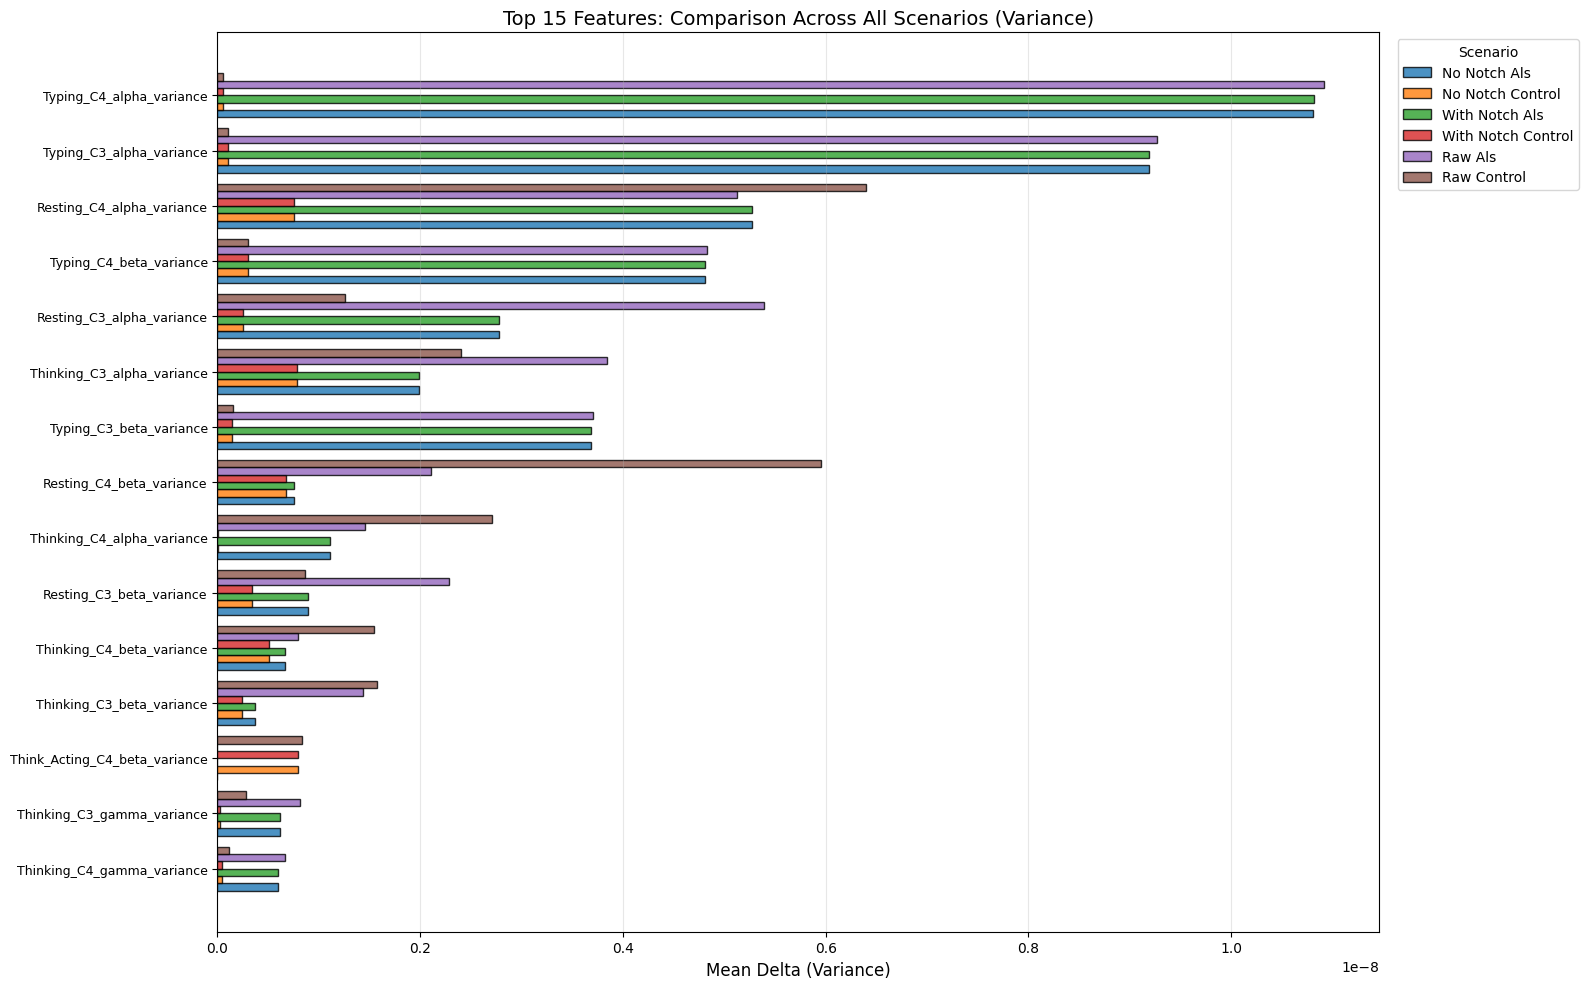

[Saved] Barplot: C:\Users\Henry\Documents\KULIAH\riset\EEG\results_task_analysis\visualizations_comparison\Variance\barplot_compare_var_delta.png


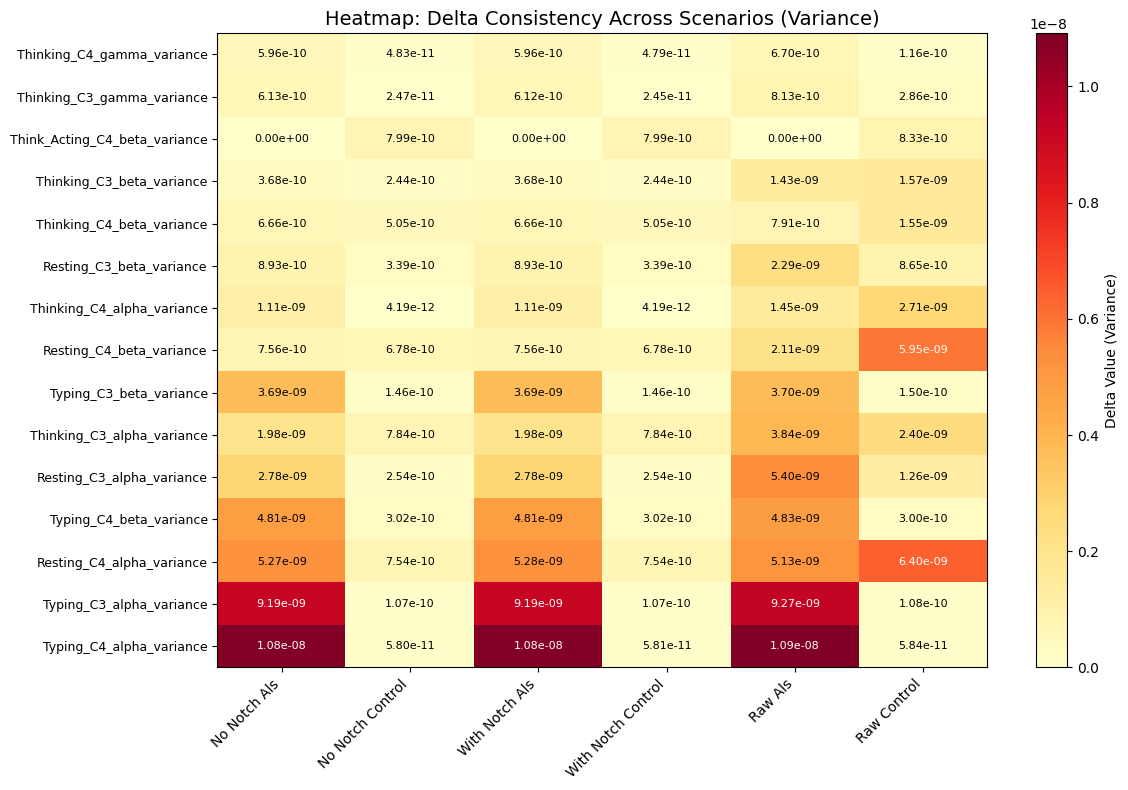

[Saved] Heatmap: C:\Users\Henry\Documents\KULIAH\riset\EEG\results_task_analysis\visualizations_comparison\Variance\heatmap_compare_var_delta.png


In [25]:
visualize_cross_scenario(dict_df, OUTPUT_BASE, metric='var_delta')


--- Processing Cross-Scenario Comparison for StdDev ---
Combined shape: (24, 6)
Scenarios found: ['No Notch Als', 'No Notch Control', 'With Notch Als', 'With Notch Control', 'Raw Als', 'Raw Control']


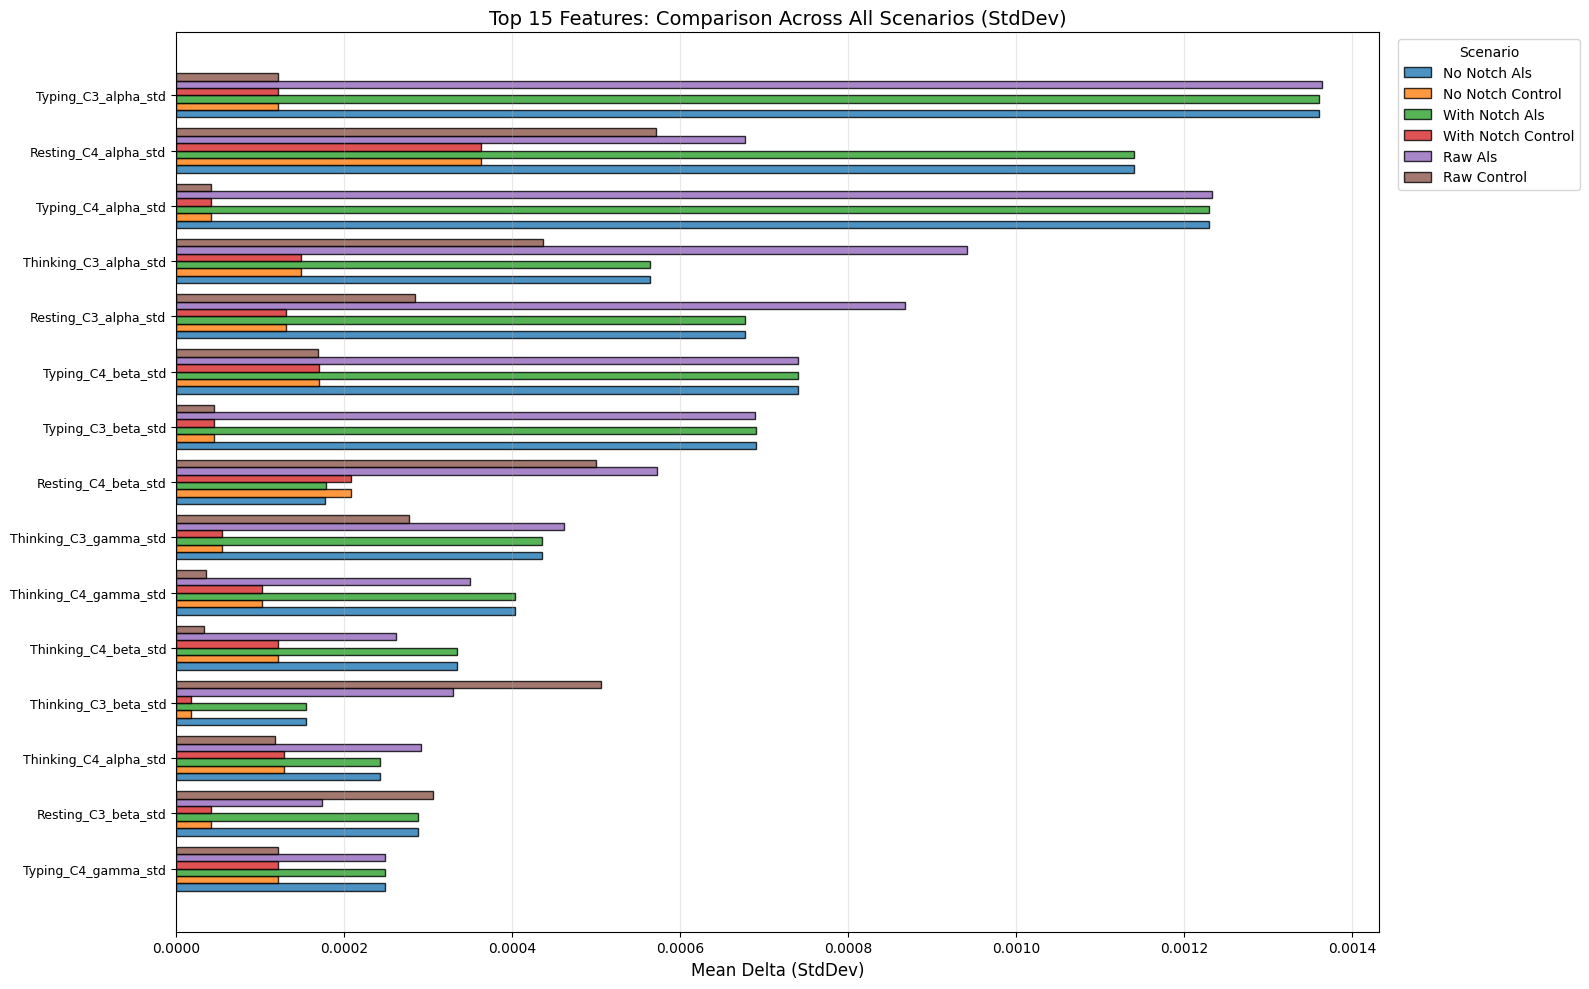

[Saved] Barplot: C:\Users\Henry\Documents\KULIAH\riset\EEG\results_task_analysis\visualizations_comparison\StdDev\barplot_compare_std_delta.png


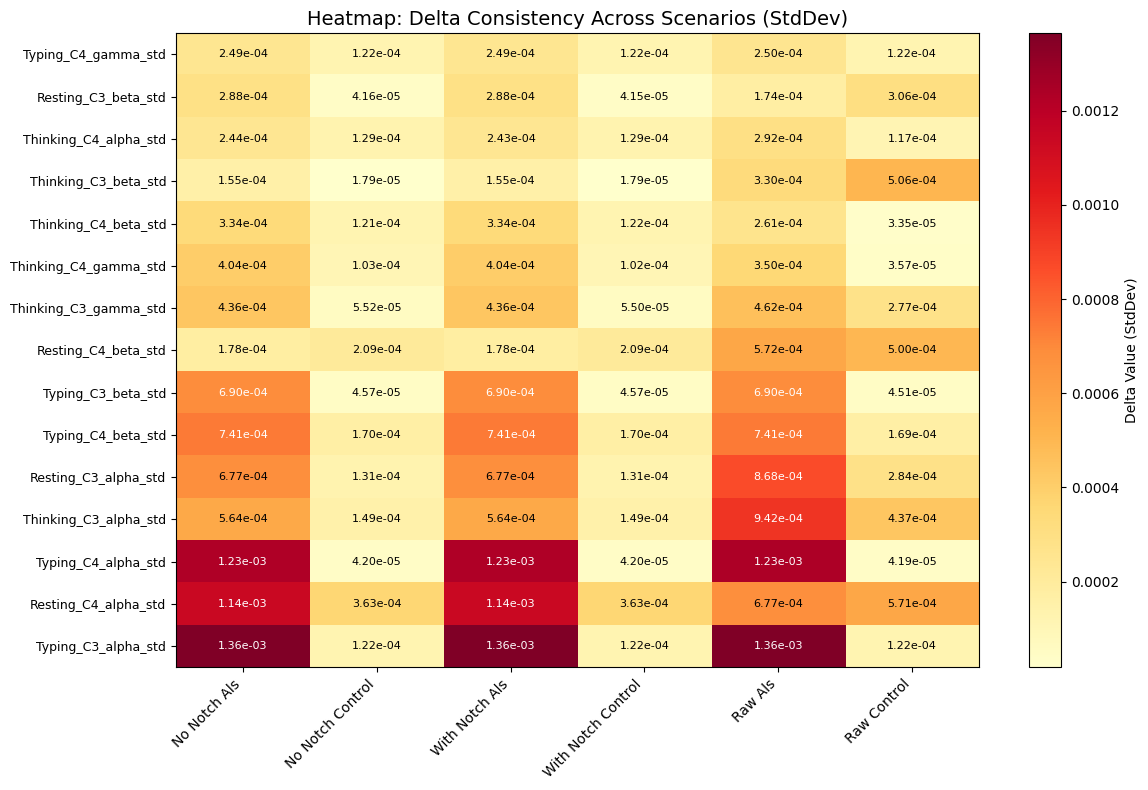

[Saved] Heatmap: C:\Users\Henry\Documents\KULIAH\riset\EEG\results_task_analysis\visualizations_comparison\StdDev\heatmap_compare_std_delta.png


In [26]:
visualize_cross_scenario(dict_df, OUTPUT_BASE, metric='std_delta')

In [31]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

def run_psd_feature_extraction(label, use_bandpass=True, use_notch=True, use_ica=True):
    """
    Menjalankan pipeline ekstraksi fitur PSD (Mean Power) dengan parameter preprocessing spesifik.
    """
    results_als = []
    results_control = []
    file_count = 0
    
    print(f"--- Starting Pipeline: {label.upper()} ---")
    
    for subject in os.listdir(DATASET_PATH):
        subject_path = os.path.join(DATASET_PATH, subject)
        if not os.path.isdir(subject_path):
            continue
        
        for time_folder in os.listdir(subject_path):
            time_path = os.path.join(subject_path, time_folder)
            if not os.path.isdir(time_path) or not time_folder.startswith('time'):
                continue
            
            for scenario in SCENARIOS:
                scenario_path = os.path.join(time_path, scenario)
                edf_file = os.path.join(scenario_path, "EEG.edf")
                
                if not os.path.exists(edf_file):
                    continue
                
                file_count += 1
                
                # Extract tasks dengan mode preprocessing yang dipilih
                # (Asumsi fungsi extract_tasks_from_edf sudah kamu definisikan sebelumnya)
                task_segments, sfreq = extract_tasks_from_edf(
                    edf_file, 
                    use_bandpass=use_bandpass,
                    use_notch=use_notch,
                    use_ica=use_ica
                )
                
                if task_segments is None:
                    continue
                
                for task_name, channels_data in task_segments.items():
                    for channel, data in channels_data.items():
                        for subband_name, (low, high) in SUBBANDS.items():
                            # Lakukan filtering ke subband
                            subband_data = bandpass_filter(data, low, high, sfreq)
                            
                            # --- CORE CALCULATION: MEAN POWER (PSD Proxy) ---
                            # Power = Rata-rata dari Kuadrat Sinyal
                            # Ini setara dengan Area Under Curve di grafik PSD Welch untuk rentang frekuensi ini
                            power_val = np.mean(subband_data ** 2)
                            
                            # Log transform (opsional, agar grafik lebih rapi karena power EEG eksponensial)
                            # power_val = 10 * np.log10(power_val) 
                            
                            group = 'ALS' if subject.startswith('ALS') else 'Control'
                            
                            record = {
                                'subject': subject,
                                'group': group,
                                'task': task_name,
                                'channel': channel,
                                'subband': subband_name,
                                'feature': 'Mean_Power', # Kita namakan Mean Power
                                'value': power_val,
                                'pipeline': label
                            }
                            
                            if group == 'ALS':
                                results_als.append(record)
                            else:
                                results_control.append(record)
                            
    
    df_als = pd.DataFrame(results_als)
    df_control = pd.DataFrame(results_control)
    
    total_rec = len(df_als) + len(df_control)
    print(f"[{label.upper()}] Finished. Processed {file_count} files. Total Records: {total_rec}")
    
    return df_als, df_control

In [33]:
# --- Jalankan pipelines dengan variabel BARU (biar gak overwrite) ---

# 1. Pipeline WITH_NOTCH
psd_df_notch_als, psd_df_notch_ctrl = run_psd_feature_extraction(
    'with_notch', use_bandpass=True, use_notch=True, use_ica=True
)

# 2. Pipeline NO_NOTCH
psd_df_no_notch_als, psd_df_no_notch_ctrl = run_psd_feature_extraction(
    'no_notch', use_bandpass=True, use_notch=False, use_ica=True
)

# 3. Pipeline RAW
psd_df_raw_als, psd_df_raw_ctrl = run_psd_feature_extraction(
    'raw', use_bandpass=False, use_notch=False, use_ica=False
)

# Gabungkan Semua untuk Visualisasi
psd_df_all = pd.concat([
    psd_df_notch_als, psd_df_notch_ctrl,
    psd_df_no_notch_als, psd_df_no_notch_ctrl,
    psd_df_raw_als, psd_df_raw_ctrl
], ignore_index=True)

print(f"\nTotal Dataframe Shape: {psd_df_all.shape}")

--- Starting Pipeline: WITH_NOTCH ---


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
c:\Users\Henry\Documents\KULIAH\riset\EEG\.venv\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Henry\Documents\KULIAH\riset\EEG\.venv\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 

[WITH_NOTCH] Finished. Processed 331 files. Total Records: 7428
--- Starting Pipeline: NO_NOTCH ---


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
c:\Users\Henry\Documents\KULIAH\riset\EEG\.venv\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
c:\Users\Henry\Documents\KULIAH\riset\EEG\.venv\lib\site-packages\sklearn\decomposition\_fastica.py:127: Con

[NO_NOTCH] Finished. Processed 331 files. Total Records: 7428
--- Starting Pipeline: RAW ---


C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Omitted 10 annotation(s) that were outside data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
C:\Users\Henry\AppData\Local\Temp\ipykernel_25316\3446624236.py:24: RuntimeWarning: Limited 1 annotation(s) that were expanding outside t

[RAW] Finished. Processed 331 files. Total Records: 7428

Total Dataframe Shape: (22284, 8)


In [45]:
def visualize_pipeline_comparison(target_band, target_channel,df, title_suffix=""):
    """
    Membuat dashboard visualisasi perbandingan Pipeline Preprocessing.
    """
    # Set style
    sns.set_style("whitegrid")
    
    # Kita ambil sampel Alpha Band di channel C3 (Motorik) sebagai contoh kasus
    # agar grafik tidak terlalu penuh
    # target_band = 'gamma' 
    # target_channel = 'C4'
    
    subset = df[(df['subband'] == target_band) & (df['channel'] == target_channel)]
    
    if len(subset) == 0:
        print("Data kosong untuk filter yang dipilih.")
        return

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # --- PLOT 1: BARPLOT (Rata-rata Power per Pipeline) ---
    # Melihat apakah Notch filter mengurangi Power secara signifikan
    sns.barplot(data=subset, x='pipeline', y='value', hue='group', ax=axes[0], palette='viridis', errorbar='sd')
    axes[0].set_title(f'Avg {target_band} Power in {target_channel}\n(Higher = More Energy/Noise)')
    axes[0].set_ylabel('Mean Power ($uV^2$)')
    axes[0].set_xlabel('Preprocessing Pipeline')
    
    # --- PLOT 2: BOXPLOT (Distribusi Data & Outlier) ---
    # Melihat apakah preprocessing mengurangi variansi/outlier (noise)
    sns.boxplot(data=subset, x='pipeline', y='value', hue='group', ax=axes[1], palette='Set2')
    axes[1].set_title(f'Distribution of Power ({target_band} - {target_channel})')
    axes[1].set_yscale('log') # Pakai Log scale biar outlier terlihat jelas
    axes[1].set_ylabel('Mean Power (Log Scale)')
    
    # --- PLOT 3: HEATMAP (Channel vs Subband - Aggregated) ---
    # Melihat global effect di semua channel untuk pipeline 'with_notch' vs 'raw'
    # Kita hitung selisih rata-rata power (Raw - With Notch)
    # Jika positif besar = Notch membuang banyak energi (kemungkinan noise)
    
    # Pivot data
    pivot_raw = df[df['pipeline']=='raw'].groupby(['channel', 'subband'])['value'].mean().unstack()
    pivot_notch = df[df['pipeline']=='with_notch'].groupby(['channel', 'subband'])['value'].mean().unstack()
    
    # Hitung Delta (Raw - Notch)
    delta_power = pivot_raw - pivot_notch
    
    sns.heatmap(delta_power, annot=True, fmt=".1e", cmap="coolwarm", ax=axes[2], cbar_kws={'label': 'Power Drop (Raw - Notch)'})
    axes[2].set_title('Power Reduction by Notch Filter\n(Red = Notch removed meaningful energy/noise)')
    
    plt.suptitle(f'PSD Pipeline Comparison {title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Panggil Fungsi Visualisasi

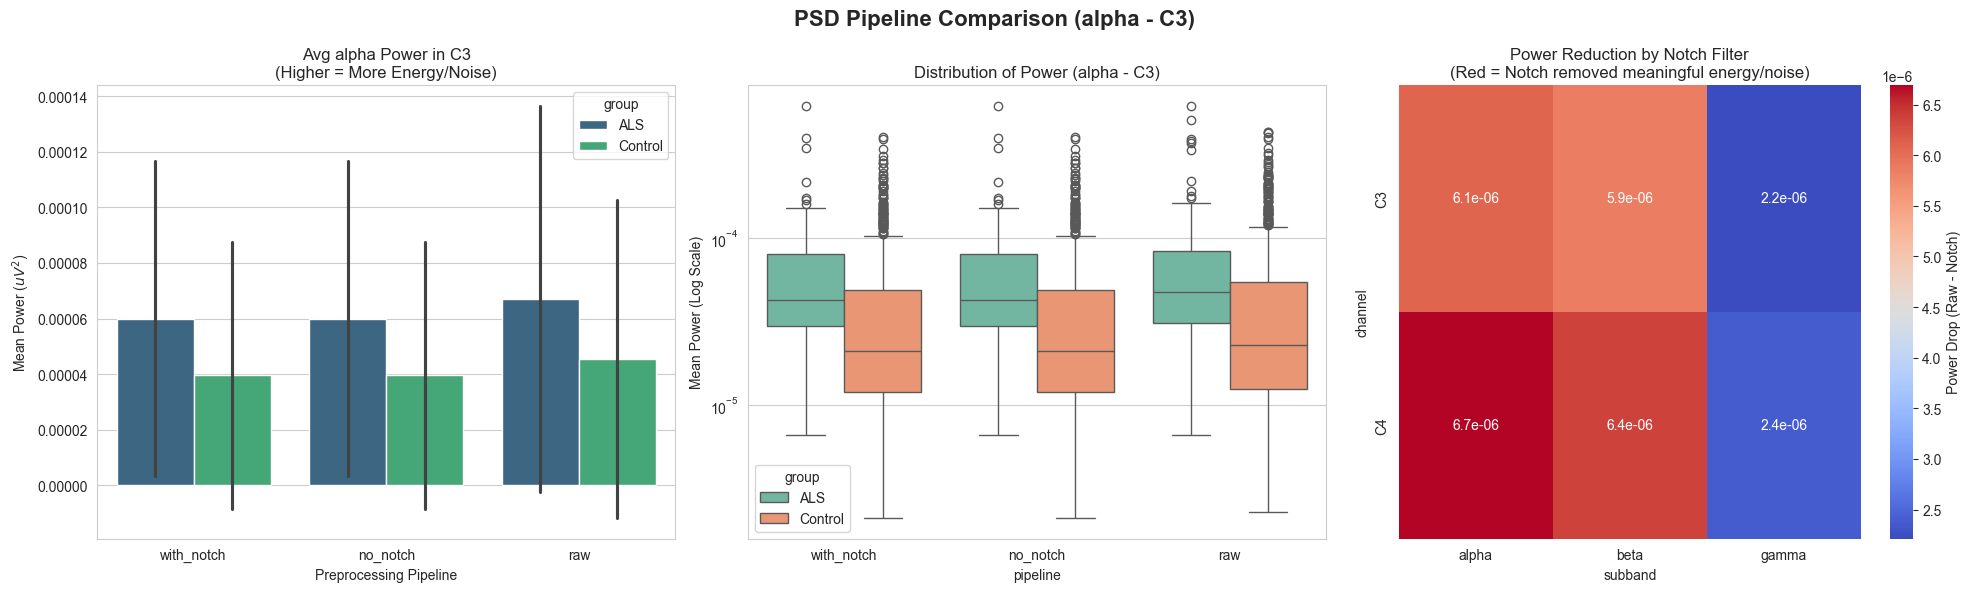

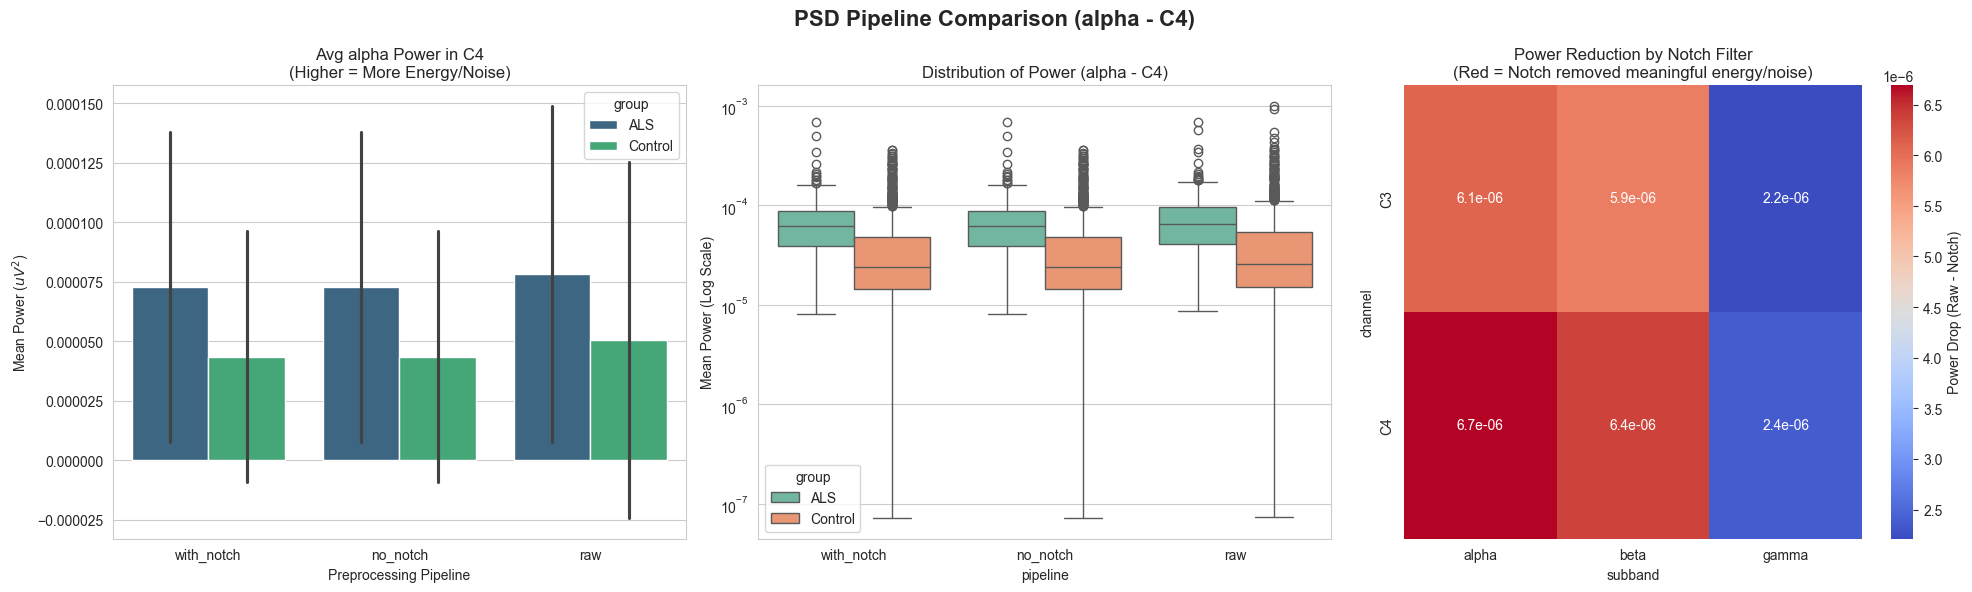

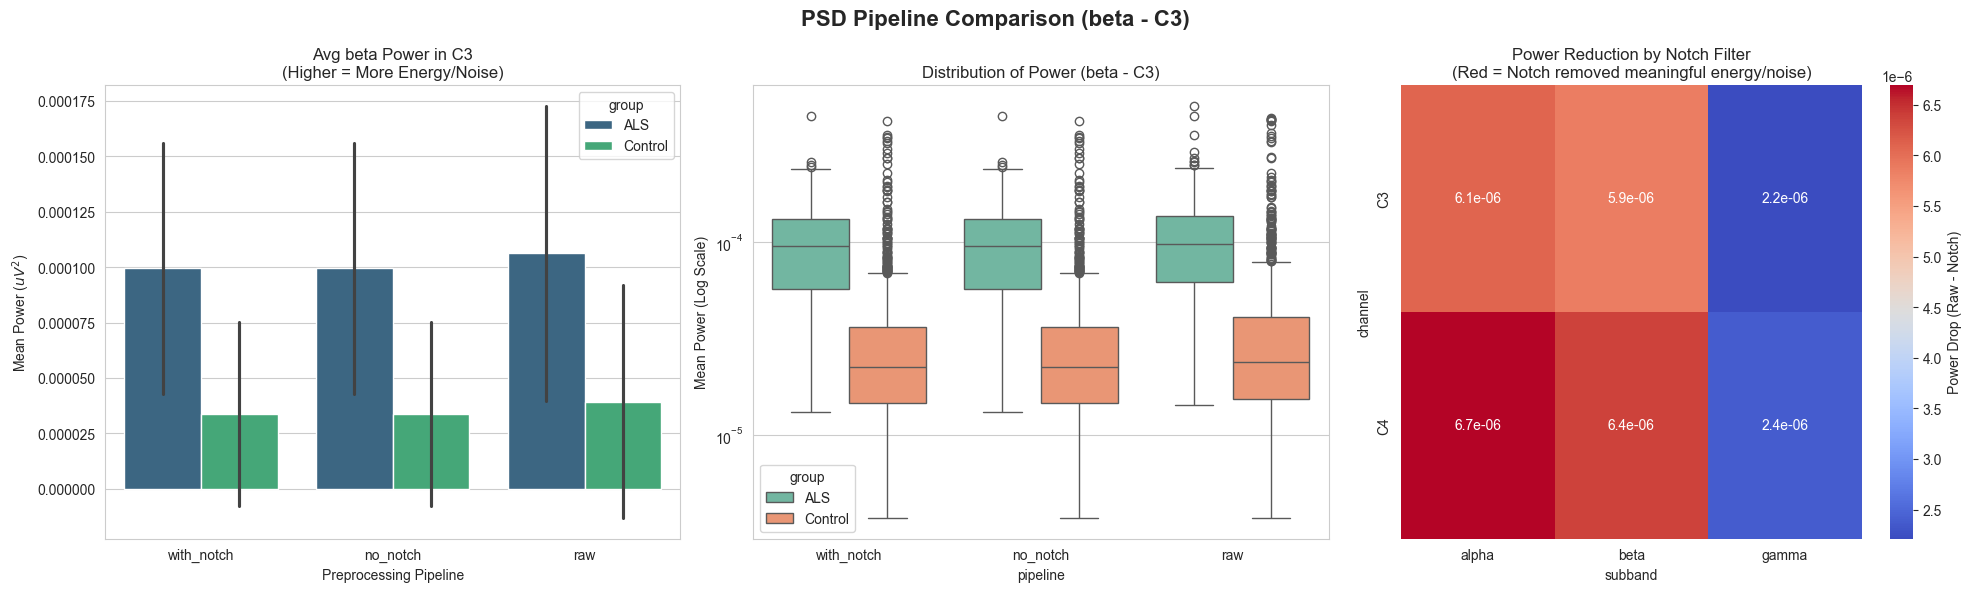

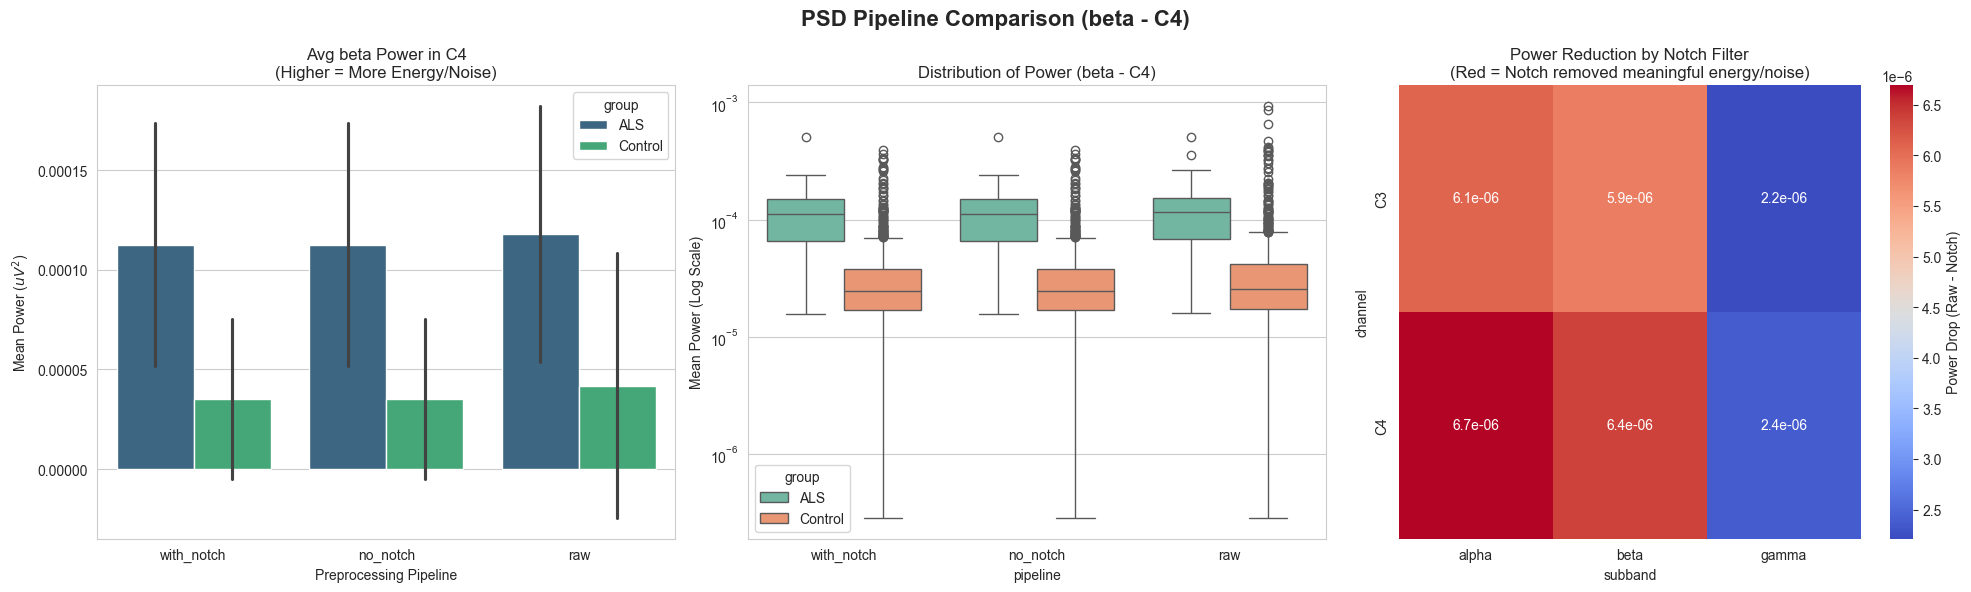

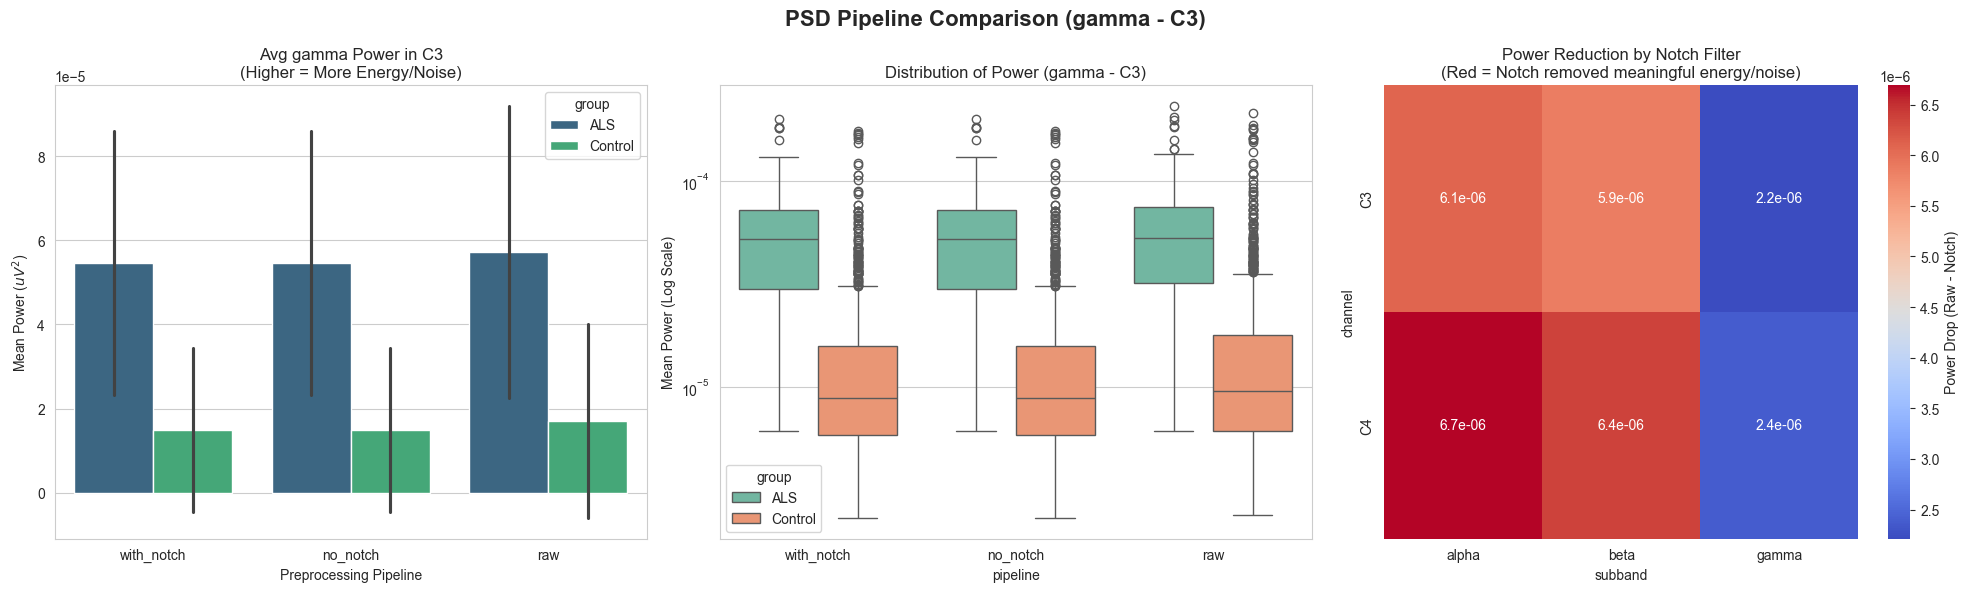

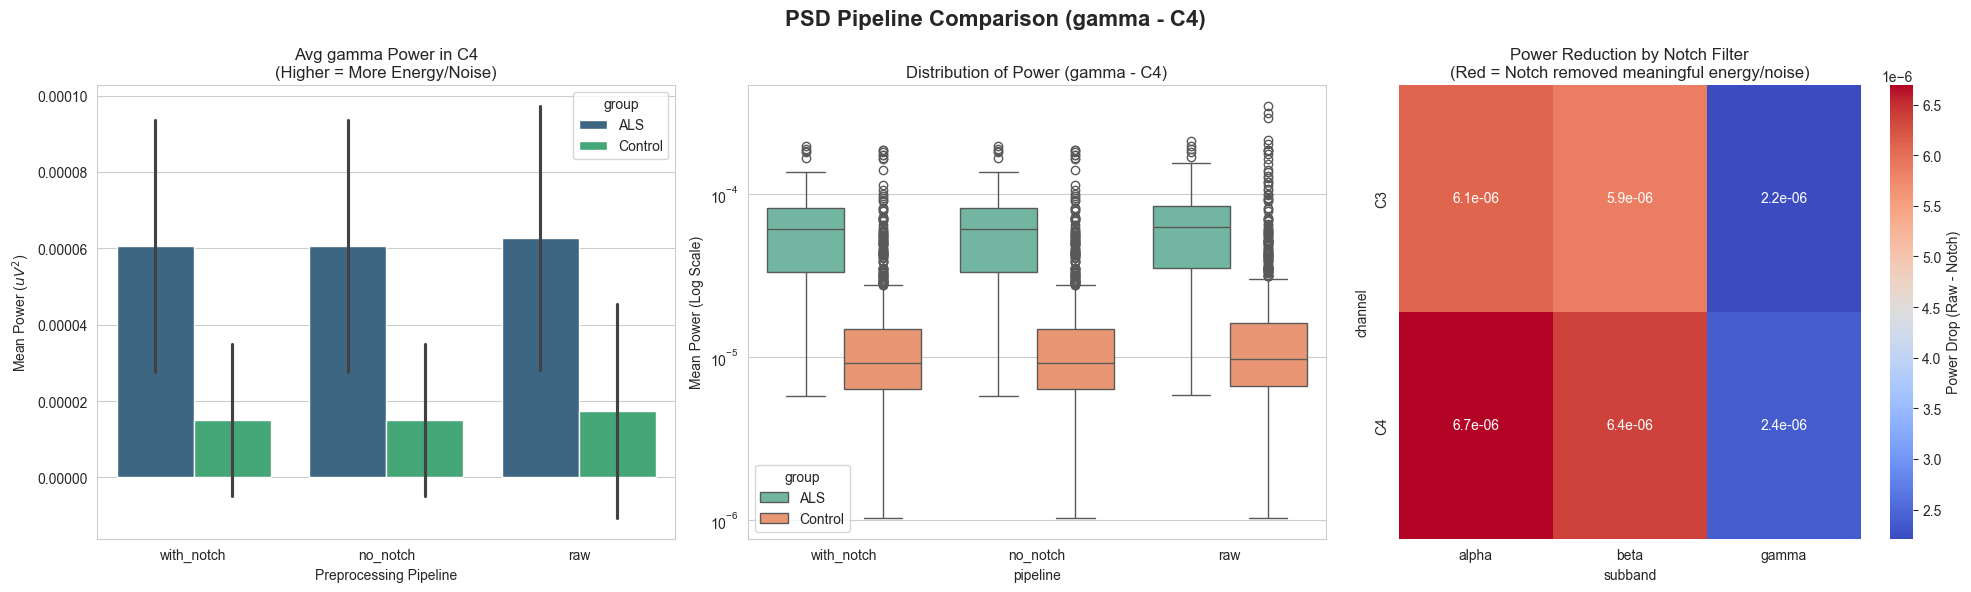

In [46]:
for subband in SUBBANDS.keys():
    for channel in CHANNELS:
        visualize_pipeline_comparison(subband, channel, psd_df_all, title_suffix=f"({subband} - {channel})")

Loading sample file: C:\Users\Henry\Documents\KULIAH\riset\EEG\EEGET-ALS Dataset\id121\time1\scenario2\EEG.edf...
Applying Bandpass Filter...
Applying Notch + Bandpass Filter...


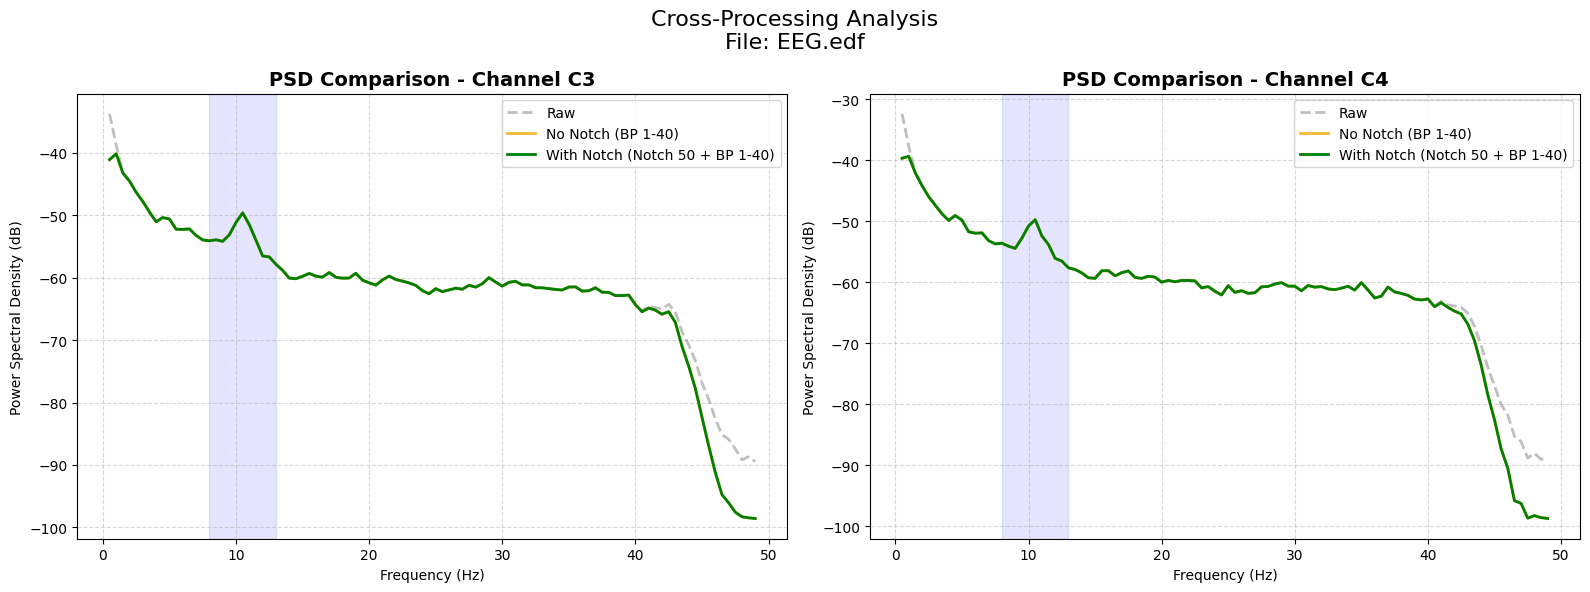

In [29]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import os

def visualize_psd_cross_processing(edf_path, fmin=0.5, fmax=49):
    """
    Membandingkan PSD dari satu file EDF dengan 3 perlakuan berbeda.
    FIXED: Key Dictionary disamakan dengan Label Plotting.
    """
    
    print(f"Loading sample file: {edf_path}...")
    
    # 1. Load RAW Data
    # Preload=True wajib agar data masuk RAM dan bisa dicopy/filter
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    
    # Copy data raw ke 3 variabel berbeda agar tidak saling timpa saat filtering
    raw_pure = raw.copy()
    raw_no_notch = raw.copy()
    raw_with_notch = raw.copy()
    
    # --- PROCESSING PIPELINE ---
    
    # A. Pipeline "No Notch" (Hanya Bandpass 1-40 Hz)
    # Kita filter sedikit lebih lebar (45) agar grafik tidak langsung mati di ujung kanan
    print("Applying Bandpass Filter...")
    raw_no_notch.filter(l_freq=1, h_freq=40, verbose=False) 
    
    # B. Pipeline "With Notch" (Notch 50 Hz + Bandpass 1-40 Hz)
    print("Applying Notch + Bandpass Filter...")
    raw_with_notch.notch_filter(freqs=50, verbose=False)
    raw_with_notch.filter(l_freq=1, h_freq=40, verbose=False)
    
    # --- PLOTTING PSD ---
    
    # Definisi Label yang KONSISTEN
    L_RAW = 'Raw'
    L_NO_NOTCH = 'No Notch (BP 1-40)'
    L_WITH_NOTCH = 'With Notch (Notch 50 + BP 1-40)'

    # Setup Style Dictionary (Kuncinya pakai variabel di atas biar gak typo/KeyError)
    colors = {L_RAW: 'grey', L_NO_NOTCH: 'orange', L_WITH_NOTCH: 'green'}
    styles = {L_RAW: '--', L_NO_NOTCH: '-', L_WITH_NOTCH: '-'}
    alphas = {L_RAW: 0.5, L_NO_NOTCH: 0.8, L_WITH_NOTCH: 1.0}
    
    # Setup Figure (2 Kolom: C3 dan C4)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    channels_to_plot = ['C3', 'C4'] # Fokus area motorik
    
    for idx, ch_name in enumerate(channels_to_plot):
        ax = axes[idx]
        
        # Helper function internal
        def plot_one_psd(inst, label):
            # Compute PSD (Welch)
            # n_fft=256 standar untuk resolusi frekuensi ~0.5 Hz
            psd = inst.compute_psd(method='welch', fmin=fmin, fmax=fmax, 
                                 picks=[ch_name], n_fft=256, verbose=False)
            data, freqs = psd.get_data(return_freqs=True)
            
            # Convert ke dB (Log scale) agar perbedaan power kecil terlihat jelas
            psd_db = 10 * np.log10(data[0]) 
            
            # Plotting dengan style dari dictionary
            ax.plot(freqs, psd_db, color=colors[label], linestyle=styles[label], 
                    alpha=alphas[label], label=label, linewidth=2)

        # Plot ketiganya dengan Label Variabel
        plot_one_psd(raw_pure, L_RAW)
        plot_one_psd(raw_no_notch, L_NO_NOTCH)
        plot_one_psd(raw_with_notch, L_WITH_NOTCH)
        
        ax.set_title(f"PSD Comparison - Channel {ch_name}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Power Spectral Density (dB)')
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        ax.legend()
        
        # Highlight Alpha Band (8-13 Hz) - Area Fokus Motor Imagery
        ax.axvspan(8, 13, color='blue', alpha=0.1, label='Alpha Band')

    plt.suptitle(f"Cross-Processing Analysis\nFile: {os.path.basename(edf_path)}", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- CARA PAKAI ---
# Ganti path ini dengan salah satu file EDF yang valid di komputermu
sample_file = "C:\\Users\\Henry\\Documents\\KULIAH\\riset\\EEG\\EEGET-ALS Dataset\\id121\\time1\\scenario2\\EEG.edf"

if os.path.exists(sample_file):
    visualize_psd_cross_processing(sample_file, fmin=0.5, fmax=49)